# E2 · MSA và tokenization trên toàn bộ Fashion-MNIST
**CO5085 · Học kỳ 261 · Notebook độc lập · Python 3.14 · CUDA**
**Restart Kernel → Run All**: kiểm tra dữ liệu/GPU → kiểm chứng MSA → huấn luyện
6 run Manual/PyTorch × 3 tokenizer → chọn tokenizer bằng validation → train H=2/H=8
→ test toàn bộ 8 model → bảng, đồ thị, confusion matrix, attention → hiển thị kết quả trong cell.

| Tập | Số ảnh | Vai trò |
|---|---:|---|
| Train | 54.000 | Cập nhật trọng số |
| Validation | 6.000 | Checkpoint, early stopping, chọn tokenizer |
| Test chính thức | 10.000 | Chỉ đánh giá sau khi khóa cả 8 thí nghiệm |

Huấn luyện trên toàn bộ train; chọn checkpoint và tokenizer bằng validation.
Batch 128, 422 batch/epoch; tối đa 100 epoch/model, patience 4, min_delta=0,0001.
Tiến trình text cập nhật tại chỗ xác nhận CUDA và gradient, giữ log chi tiết trong RAM.
Bản ManualMSA dùng phép toán cơ bản; nn.MultiheadAttention chỉ nằm trong bản reference.
Notebook chứa toàn bộ code, không import notebook/module bài khác.

## 1. Môi trường, GPU và cấu hình

In [1]:
import copy
import hashlib
import importlib.metadata
import json
import math
import os
import random
import sys
import time
from datetime import datetime, timezone
from pathlib import Path
from uuid import uuid4

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from IPython.display import Markdown, display
from matplotlib.ticker import MaxNLocator
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

torch.set_num_threads(min(8, os.cpu_count() or 1))
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

SESSION_STARTED = time.perf_counter()
EXECUTION_LOG = []


def log(stage, message, model=None, *, console=True):
    prefix = f"[{time.strftime('%H:%M:%S')}] [{stage}]"
    if model:
        prefix += f" [{model}]"
    line = f"{prefix} {message}"
    EXECUTION_LOG.append(line)
    if console:
        print(line, flush=True)


log("MÔI TRƯỜNG", "Đã import PyTorch, NumPy, Matplotlib và tiện ích báo cáo.")


class TextProgress:
    """Update one plain-text display per model without clearing other outputs."""

    def __init__(self, model):
        self.model = model
        self.started = time.perf_counter()
        self.phase_started = self.started
        self.last_refresh = 0.0
        self.state = {
            "phase": "Chuẩn bị",
            "epoch": 0,
            "max_epochs": MAX_EPOCHS,
            "step": 0,
            "batches": 0,
            "samples": 0,
            "total_samples": 0,
            "loss": None,
            "accuracy": None,
            "updates": 0,
            "skips": 0,
            "vram": 0.0,
            "train_verified": False,
            "eval_verified": False,
            "validation": "Chưa đánh giá",
            "test": "Chưa đánh giá",
            "checkpoint": "Chưa chọn",
            "bad": 0,
            "patience": EARLY_STOP_PATIENCE,
            "min_delta": EARLY_STOP_MIN_DELTA,
            "status": "Khởi tạo model",
        }
        self.gpu = torch.cuda.get_device_name(DEVICE)
        self.handle = display({"text/plain": self.render()}, raw=True, display_id=True)

    @staticmethod
    def bar(current, total, width=24):
        fraction = min(1.0, max(0.0, current / total)) if total else 0.0
        filled = int(width * fraction)
        return "[" + "#" * filled + "-" * (width - filled) + f"] {100 * fraction:5.1f}%"

    @staticmethod
    def duration(seconds):
        minutes, seconds = divmod(max(0, int(seconds)), 60)
        hours, minutes = divmod(minutes, 60)
        return f"{hours:02}:{minutes:02}:{seconds:02}"

    def start_phase(self, phase, batches, total_samples, **changes):
        self.phase_started = time.perf_counter()
        self.update(
            force=True,
            phase=phase,
            batches=batches,
            total_samples=total_samples,
            step=0,
            samples=0,
            loss=None,
            accuracy=None,
            **changes,
        )

    def update(self, *, force=False, **changes):
        self.state.update(changes)
        now = time.perf_counter()
        if not force and now - self.last_refresh < PROGRESS_REFRESH_SECONDS:
            return
        payload = {"text/plain": self.render()}
        if self.handle is not None:
            self.handle.update(payload, raw=True)
        self.last_refresh = now

    def render(self):
        s = self.state
        elapsed = time.perf_counter() - self.started
        phase_elapsed = time.perf_counter() - self.phase_started
        eta = (
            self.duration(phase_elapsed * (s["batches"] - s["step"]) / s["step"])
            if s["step"]
            else "--:--:--"
        )
        loss = f"{s['loss']:.4f}" if s["loss"] is not None else "----"
        accuracy = (
            f"{100 * s['accuracy']:.2f}%" if s["accuracy"] is not None else "----"
        )
        train_proof = (
            "parameters/images/labels/logits/gradient: CUDA xác nhận"
            if s["train_verified"]
            else "train: chờ xác nhận tensor/gradient CUDA"
        )
        eval_proof = " | eval: CUDA xác nhận" if s["eval_verified"] else ""
        return "\n".join(
            [
                f"{self.model} | GPU: {self.gpu} | device={DEVICE} | AMP train",
                f"Epoch {s['epoch']}/{s['max_epochs']} (giới hạn; có early stopping)",
                f"{s['phase']} {self.bar(s['step'], s['batches'])} | batch {s['step']}/{s['batches']} | ảnh {s['samples']:,}/{s['total_samples']:,}",
                f"Loss={loss} | Accuracy={accuracy} | Updates train/epoch={s['updates']} | AMP skips train/epoch={s['skips']} | VRAM={s['vram']:.0f} MiB",
                f"Validation: {s['validation']}",
                f"Test: {s['test']}",
                f"Checkpoint: {s['checkpoint']} | Early stop={s['bad']}/{s['patience']} | min_delta={s['min_delta']:g}",
                train_proof + eval_proof,
                f"Thời gian từ khi bắt đầu run={self.duration(elapsed)} | ETA pha hiện tại≈{eta} | {s['status']}",
            ]
        )

[02:29:17] [MÔI TRƯỜNG] Đã import PyTorch, NumPy, Matplotlib và tiện ích báo cáo.


In [2]:
NAME = "E2"
DATA_SCOPE = "Fashion-MNIST đầy đủ"
SEED = 42
BATCH_SIZE = 128
MAX_EPOCHS = 100
EARLY_STOP_PATIENCE = 4
EARLY_STOP_MIN_DELTA = 1e-4
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
LOG_BATCH_EVERY = 50  # Chỉ ghi log chi tiết trong RAM; không in từng batch.
PROGRESS_REFRESH_SECONDS = 0.25  # Giới hạn tần suất cập nhật display text.
NUM_WORKERS = 0  # Data đã ở RAM; Windows notebook không spawn worker local.
if not torch.cuda.is_available():
    raise RuntimeError(
        "E2 bắt buộc GPU CUDA. Chọn kernel Python 3.14 (CO5085) với PyTorch CUDA; "
        "kiểm tra torch.cuda.is_available(). Notebook không chuyển ngầm sang CPU."
    )
DEVICE = torch.device("cuda:0")
ROOT = next(
    (
        p
        for p in [Path.cwd(), *Path.cwd().parents]
        if (p / "assignment" / "exercise-vne.pdf").is_file()
    ),
    None,
)
if ROOT is None:
    raise RuntimeError("Open this notebook from CO5085 or source_code.")
RUN_ID = (
    datetime.now(timezone.utc).astimezone().strftime("%Y%m%d_%H%M%S")
    + "_"
    + uuid4().hex[:6]
)
RUN_CONFIGS = {}

CHECKPOINTS = {}


TOKEN_LABELS = {"rows": "Rows", "patches": "Patch 4×4", "stem": "CNN-stem"}
MODEL_LABELS, MODEL_TICKS, MODEL_COLORS, MODEL_CURVE_LABELS = {}, {}, {}, {}
for implementation in ["manual", "reference"]:
    family = "Manual MSA" if implementation == "manual" else "PyTorch MSA"
    for tokenizer, label in TOKEN_LABELS.items():
        run = f"{implementation}_{tokenizer}"
        MODEL_LABELS[run] = f"{family} · {label} · H=4"
        MODEL_TICKS[run] = (
            "Manual" if implementation == "manual" else "PyTorch"
        ) + f"\n{label}\nH=4"
        MODEL_COLORS[run] = "#0072B2" if implementation == "manual" else "#E69F00"
        MODEL_CURVE_LABELS[run] = "Manual" if implementation == "manual" else "PyTorch"
for tokenizer, label in TOKEN_LABELS.items():
    for heads, color in [(2, "#009E73"), (8, "#CC79A7")]:
        run = f"manual_{tokenizer}_heads{heads}"
        MODEL_LABELS[run] = f"Manual MSA · {label} · H={heads}"
        MODEL_TICKS[run] = f"Manual\n{label}\nH={heads}"
        MODEL_COLORS[run] = color
        MODEL_CURVE_LABELS[run] = f"H={heads}"


VERSIONS = {
    p: importlib.metadata.version(p)
    for p in ["torch", "torchvision", "numpy", "matplotlib", "Pillow"]
}
properties = torch.cuda.get_device_properties(DEVICE)
log("CẤU HÌNH", f"{DATA_SCOPE} | run={RUN_ID} | seed={SEED} | huấn luyện")
log(
    "GPU",
    f"CUDA available=True | device={DEVICE} | {properties.name} | VRAM tổng={properties.total_memory / 2**30:.2f} GiB | torch CUDA={torch.version.cuda}",
)
log("PYTHON", f"{sys.version.split()[0]} | interpreter={sys.executable}")
log("PHIÊN BẢN", ", ".join(f"{p}={v}" for p, v in VERSIONS.items()))
log(
    "CẤU HÌNH",
    f"batch={BATCH_SIZE} | tối đa {MAX_EPOCHS} epoch | AdamW lr={LEARNING_RATE:g}, wd={WEIGHT_DECAY:g}",
)
log(
    "EARLY STOPPING",
    f"Monitor validation loss | min_delta={EARLY_STOP_MIN_DELTA:g} | patience={EARLY_STOP_PATIENCE} epoch",
)
log("KẾT QUẢ", "Kết quả trong output cell; checkpoint tốt nhất giữ trong RAM.")
probe = torch.randn(64, 64, device=DEVICE)
probe_result = probe @ probe
torch.cuda.synchronize()
assert probe.is_cuda and probe_result.is_cuda
log(
    "GPU PREFLIGHT",
    f"Phép nhân tensor đã chạy trên {probe_result.device}; CUDA hoạt động.",
)
del probe, probe_result
log(
    "HIỂN THỊ",
    "Train/validation/test cập nhật một khung text/model tại chỗ; log chi tiết giữ trong EXECUTION_LOG (RAM).",
)

[02:29:17] [CẤU HÌNH] Fashion-MNIST đầy đủ | run=20261007_022917_81ff28 | seed=42 | huấn luyện
[02:29:17] [GPU] CUDA available=True | device=cuda:0 | NVIDIA RTX A3000 12GB Laptop GPU | VRAM tổng=12.00 GiB | torch CUDA=12.8
[02:29:17] [PYTHON] 3.14.7 | interpreter=C:\Users\DELL\AppData\Local\Programs\Python\Python314\python.exe
[02:29:17] [PHIÊN BẢN] torch=2.11.0+cu128, torchvision=0.26.0+cu128, numpy=2.5.2, matplotlib=3.11.2, Pillow=12.3.0
[02:29:17] [CẤU HÌNH] batch=128 | tối đa 100 epoch | AdamW lr=0.001, wd=0.0001
[02:29:17] [EARLY STOPPING] Monitor validation loss | min_delta=0.0001 | patience=10 epoch
[02:29:17] [KẾT QUẢ] Kết quả trong output cell; checkpoint tốt nhất giữ trong RAM.
[02:29:17] [GPU PREFLIGHT] Phép nhân tensor đã chạy trên cuda:0; CUDA hoạt động.
[02:29:17] [HIỂN THỊ] Train/validation/test cập nhật một khung text/model tại chỗ; log chi tiết giữ trong EXECUTION_LOG (RAM).


### Tiện ích tái lập, checkpoint RAM và trình bày kết quả

In [3]:
def seed_all(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


def digest(value):
    return hashlib.sha256(
        json.dumps(value, sort_keys=True, default=str).encode()
    ).hexdigest()


def snapshot(value):
    """Freeze CPU tensor/array copies so later training cannot change a best state."""
    if torch.is_tensor(value):
        return value.detach().cpu().clone()
    if isinstance(value, np.ndarray):
        return value.copy()
    if isinstance(value, dict):
        return {key: snapshot(item) for key, item in value.items()}
    if isinstance(value, list):
        return [snapshot(item) for item in value]
    if isinstance(value, tuple):
        return tuple(snapshot(item) for item in value)
    return copy.deepcopy(value)


def remember_checkpoint(run, state):
    """Freeze the best model's weights in CPU RAM."""
    CHECKPOINTS[run] = snapshot(state)


def load_checkpoint(run):
    """Return the validation-selected weights for this experiment."""
    return CHECKPOINTS[run]


def show_figure(fig, stem):
    if fig.get_layout_engine() is None:
        fig.tight_layout()
    print(f"[HÌNH] {stem} · hiển thị trong output cell", flush=True)
    plt.show()
    plt.close(fig)


def finish_notebook():
    CHECKPOINTS.clear()
    log("THÍ NGHIỆM", f"Hoàn tất đánh giá {len(results)} model trên toàn bộ test.")


seed_all(SEED)
log("TIỆN ÍCH", "Đã định nghĩa seed, protocol, checkpoint RAM và trình bày bảng/hình.")

[02:29:17] [TIỆN ÍCH] Đã định nghĩa seed, protocol, checkpoint RAM và trình bày bảng/hình.


## 2. Toàn bộ Fashion-MNIST và split độc lập
Đọc/checksum đủ 54.000 train, 6.000 validation, 10.000 test. Normalization chỉ từ train; không lấy tập con. Kiểm tra split hash và train/validation không giao nhau.

In [4]:
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]
CACHE = Path(
    os.environ.get("FASHION_MNIST_ROOT", str(ROOT / "datasets" / "fashion_mnist"))
)
log("DỮ LIỆU", f"Đọc Fashion-MNIST: {CACHE}")
metadata_path = CACHE / "metadata.json"
if not metadata_path.is_file():
    raise FileNotFoundError(
        f"Prepared Fashion-MNIST missing: {metadata_path}. Copy datasets/fashion_mnist with train/val/test."
    )
METADATA = json.loads(metadata_path.read_text(encoding="utf-8"))
assert METADATA["schema"] == 1 and METADATA["seed"] == 42
mean, std = METADATA["normalization"]["mean"], METADATA["normalization"]["std"]
assert math.isfinite(mean) and math.isfinite(std) and 0 < std <= 1 and 0 <= mean <= 1


def prepared_fashion(split):
    started = time.perf_counter()
    log("KIỂM TRA DỮ LIỆU", f"Đọc/checksum split {split}.")
    folder = CACHE / split
    for filename, checksum in METADATA["splits"][split]["sha256"].items():
        with (folder / filename).open("rb") as stream:
            assert hashlib.file_digest(stream, "sha256").hexdigest() == checksum, (
                filename
            )
    pixels = np.load(folder / "images.npy", allow_pickle=False)
    labels = np.load(folder / "labels.npy", allow_pickle=False)
    index_array = np.load(folder / "indices.npy", allow_pickle=False)
    assert labels.ndim == 1 and np.issubdtype(labels.dtype, np.integer)
    assert ((labels >= 0) & (labels < len(CLASS_NAMES))).all()
    assert index_array.shape == labels.shape and np.issubdtype(
        index_array.dtype, np.integer
    )
    assert len(np.unique(index_array)) == len(index_array)
    source_size = 10000 if split == "test" else 60000
    assert ((index_array >= 0) & (index_array < source_size)).all()
    indices = index_array.tolist()
    assert pixels.dtype == np.uint8 and pixels.shape == (len(labels), 28, 28)
    assert len(labels) == METADATA["splits"][split]["count"]
    images = (torch.from_numpy(pixels).float().unsqueeze(1) / 255 - mean) / std
    log(
        "KIỂM TRA DỮ LIỆU",
        f"{split}: {len(labels):,} ảnh, shape={tuple(images.shape)}, hợp lệ ({time.perf_counter() - started:.2f}s).",
    )
    return TensorDataset(images, torch.from_numpy(labels.astype(np.int64))), indices


train_set, train_indices = prepared_fashion("train")
val_set, val_indices = prepared_fashion("val")
test_set, _ = prepared_fashion("test")
assert len(train_set) == 54000 and len(val_set) == 6000 and len(test_set) == 10000
assert not set(train_indices) & set(val_indices)
assert sorted(train_indices + val_indices) == list(range(60000))
SPLIT_HASH = digest(
    {"train": train_indices, "val": val_indices, "normalization": [mean, std]}
)
assert SPLIT_HASH == METADATA["split_hash"]


def dataset_labels(dataset):
    return dataset.tensors[1].numpy()


log(
    "SPLIT",
    f"{len(train_set):,} train / {len(val_set):,} validation; test có {len(test_set):,} ảnh.",
)
log("SPLIT", f"Hash={SPLIT_HASH}, mean={mean:.6f}, std={std:.6f}")
display(
    Markdown(
        "| Tập | Đầy đủ | Dùng lần này | Vai trò |\n|---|---:|---:|---|\n"
        f"| Train | 54.000 | {len(train_set):,} | Cập nhật trọng số |\n"
        f"| Validation | 6.000 | {len(val_set):,} | Chọn checkpoint, early stopping |\n"
        f"| Test | 10.000 | {len(test_set):,} | Đánh giá sau chọn checkpoint |"
    )
)
log(
    "MINI-BATCH",
    f"Train {math.ceil(len(train_set) / BATCH_SIZE)} batch/epoch; validation {math.ceil(len(val_set) / BATCH_SIZE)} batch; test {math.ceil(len(test_set) / BATCH_SIZE)} batch; không bỏ batch cuối.",
)

[02:29:17] [DỮ LIỆU] Đọc Fashion-MNIST: C:\Users\DELL\Desktop\CO5085\datasets\fashion_mnist
[02:29:17] [KIỂM TRA DỮ LIỆU] Đọc/checksum split train.
[02:29:17] [KIỂM TRA DỮ LIỆU] train: 54,000 ảnh, shape=(54000, 1, 28, 28), hợp lệ (0.22s).
[02:29:17] [KIỂM TRA DỮ LIỆU] Đọc/checksum split val.
[02:29:17] [KIỂM TRA DỮ LIỆU] val: 6,000 ảnh, shape=(6000, 1, 28, 28), hợp lệ (0.01s).
[02:29:17] [KIỂM TRA DỮ LIỆU] Đọc/checksum split test.
[02:29:17] [KIỂM TRA DỮ LIỆU] test: 10,000 ảnh, shape=(10000, 1, 28, 28), hợp lệ (0.02s).
[02:29:17] [SPLIT] 54,000 train / 6,000 validation; test có 10,000 ảnh.
[02:29:17] [SPLIT] Hash=bd9f3884131e411a26892e15ff685f2849216340505ea615f3fb3b901e30fe80, mean=0.285886, std=0.352960
[02:29:17] [MINI-BATCH] Train 422 batch/epoch; validation 47 batch; test 79 batch; không bỏ batch cuối.


| Tập | Đầy đủ | Dùng lần này | Vai trò |
|---|---:|---:|---|
| Train | 54.000 | 54,000 | Cập nhật trọng số |
| Validation | 6.000 | 6,000 | Chọn checkpoint, early stopping |
| Test | 10.000 | 10,000 | Đánh giá sau chọn checkpoint |

## 3. Khảo sát dữ liệu
Ảnh mẫu ghi tên lớp, biểu đồ số lượng đặt ngang. Cả ba tập được giữ đầy đủ.

[02:29:17] [EDA] Gộp ví dụ 10 lớp và phân bố train/validation trong một hình.
[HÌNH] dataset_overview · hiển thị trong output cell


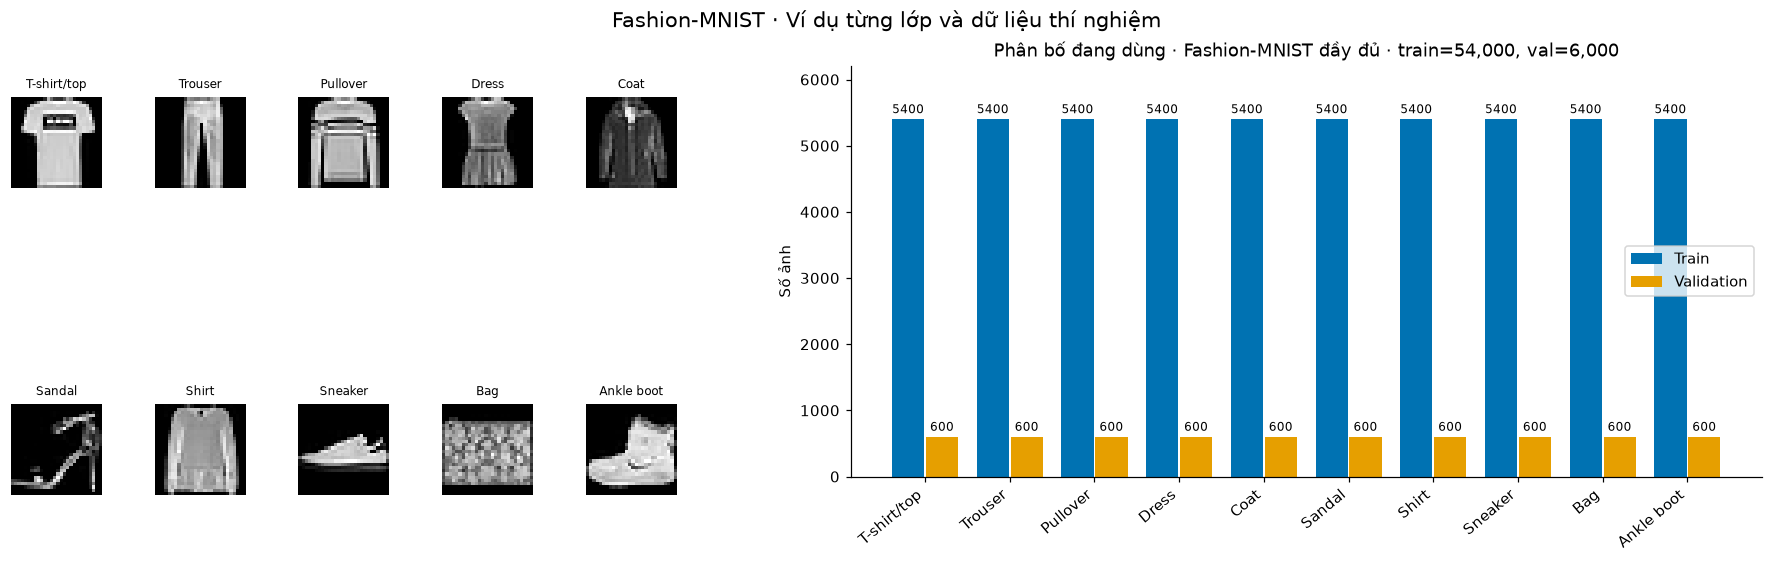

In [5]:
log("EDA", "Gộp ví dụ 10 lớp và phân bố train/validation trong một hình.")
eda_images = np.load(CACHE / "train/images.npy", mmap_mode="r", allow_pickle=False)
eda_labels = np.load(CACHE / "train/labels.npy", allow_pickle=False)
fig = plt.figure(figsize=(16, 5), layout="constrained")
grid = fig.add_gridspec(1, 2, width_ratios=[1, 1.35], wspace=0.22)
gallery = grid[0].subgridspec(2, 5, wspace=0.15, hspace=0.38)
for label in range(10):
    ax = fig.add_subplot(gallery[label // 5, label % 5])
    ax.imshow(eda_images[np.flatnonzero(eda_labels == label)[0]], cmap="gray")
    ax.set_title(CLASS_NAMES[label], fontsize=8)
    ax.axis("off")
ax = fig.add_subplot(grid[1])
positions = np.arange(10)
for offset, dataset, label, color in [
    (-0.2, train_set, "Train", "#0072B2"),
    (0.2, val_set, "Validation", "#E69F00"),
]:
    counts = np.bincount(dataset_labels(dataset), minlength=10)
    bars = ax.bar(positions + offset, counts, width=0.38, label=label, color=color)
    ax.bar_label(bars, fontsize=8, padding=2)
ax.set_xticks(positions, CLASS_NAMES, rotation=40, ha="right")
ax.set_ylabel("Số ảnh")
ax.set_title(
    f"Phân bố đang dùng · {DATA_SCOPE} · train={len(train_set):,}, val={len(val_set):,}"
)
ax.margins(y=0.15)
ax.legend()
fig.suptitle("Fashion-MNIST · Ví dụ từng lớp và dữ liệu thí nghiệm", fontsize=14)
show_figure(fig, "dataset_overview")

## 4. MSA thủ công, reference và ba tokenizer
Rows: 28 token × 28 feature; patch 4×4: 49 token × 16 feature theo raster;
CNN-stem: 7×7 vị trí, mỗi token 16 feature. Learned positional embedding, D=64,
2 encoder block pre-norm, H=4, FFN ratio 2, mean pooling và head 10 logits.
Không softmax trước cross-entropy. Manual chỉ Linear/reshape/matmul/softmax;
reference dùng PyTorch MHA. H=2/H=8 là ablation thêm sau 6 run chính.
Các cặp Manual/PyTorch cùng tokenizer dùng cùng trọng số khởi tạo, gồm embedding/position/FFN/head. RNG được reset theo cùng seed trước training; dropout có thể sử dụng RNG khác giữa hai implementation.

In [6]:
class ManualMSA(nn.Module):
    """Multi-head self-attention built from projection, matmul and softmax."""

    def __init__(self, dim=64, heads=4, dropout=0.1):
        super().__init__()
        if heads < 1 or dim % heads != 0:
            raise ValueError("Embedding dimension must be divisible by heads.")
        self.heads, self.head_dim = heads, dim // heads
        self.qkv = nn.Linear(dim, dim * 3)
        self.proj = nn.Linear(dim, dim)
        self.drop = nn.Dropout(dropout)
        self.attention = None

    def forward(self, x):
        batch, tokens, dim = x.shape
        qkv = self.qkv(x).reshape(batch, tokens, 3, self.heads, self.head_dim)
        q, k, v = qkv.permute(2, 0, 3, 1, 4).unbind(0)
        weights = (q @ k.transpose(-2, -1) / math.sqrt(self.head_dim)).softmax(-1)
        self.attention = weights.detach()
        y = (self.drop(weights) @ v).transpose(1, 2).reshape(batch, tokens, dim)
        return self.proj(y)


class ReferenceMSA(nn.Module):
    def __init__(self, dim=64, heads=4, dropout=0.1):
        super().__init__()
        self.mha = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.attention = None

    def forward(self, x):
        y, weights = self.mha(x, x, x, need_weights=True, average_attn_weights=False)
        self.attention = weights.detach()
        return y


class EncoderBlock(nn.Module):
    def __init__(self, reference=False, dim=64, heads=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = (ReferenceMSA if reference else ManualMSA)(dim, heads)
        self.norm2 = nn.LayerNorm(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(dim * 2, dim),
            nn.Dropout(0.1),
        )
        self.drop = nn.Dropout(0.1)

    def forward(self, x):
        x = x + self.drop(self.attn(self.norm1(x)))
        return x + self.ff(self.norm2(x))


class TokenClassifier(nn.Module):
    def __init__(self, tokenizer, reference=False, heads=4):
        super().__init__()
        if tokenizer not in TOKEN_LABELS:
            raise ValueError(f"Unknown tokenizer: {tokenizer}")
        self.tokenizer = tokenizer
        tokens, features = (28, 28) if tokenizer == "rows" else (49, 16)
        if tokenizer == "stem":
            self.stem = nn.Sequential(
                nn.Conv2d(1, 16, 3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(16, 16, 3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),
            )
        self.embedding = nn.Linear(features, 64)
        self.position = nn.Parameter(torch.randn(1, tokens, 64) * 0.02)
        self.blocks = nn.Sequential(
            EncoderBlock(reference, heads=heads), EncoderBlock(reference, heads=heads)
        )
        self.norm = nn.LayerNorm(64)
        self.head = nn.Linear(64, 10)

    def tokenize(self, x):
        if self.tokenizer == "rows":
            return x[:, 0]
        if self.tokenizer == "patches":
            return F.unfold(x, kernel_size=4, stride=4).transpose(1, 2)
        return self.stem(x).flatten(2).transpose(1, 2)

    def forward(self, x):
        x = self.embedding(self.tokenize(x)) + self.position
        return self.head(self.norm(self.blocks(x)).mean(1))


SPECS = {
    f"{implementation}_{tokenizer}": {
        "implementation": implementation,
        "tokenizer": tokenizer,
        "heads": 4,
        "token_count": 28 if tokenizer == "rows" else 49,
    }
    for implementation in ["manual", "reference"]
    for tokenizer in TOKEN_LABELS
}
BASE_RUNS = list(SPECS)


def manual_state_key(reference_key):
    substitutions = {
        ".attn.mha.in_proj_weight": ".attn.qkv.weight",
        ".attn.mha.in_proj_bias": ".attn.qkv.bias",
        ".attn.mha.out_proj.weight": ".attn.proj.weight",
        ".attn.mha.out_proj.bias": ".attn.proj.bias",
    }
    for suffix, replacement in substitutions.items():
        reference_key = reference_key.replace(suffix, replacement)
    return reference_key


def make_model(run):
    spec = SPECS[run]
    if spec["implementation"] == "manual":
        return TokenClassifier(spec["tokenizer"], heads=spec["heads"])
    # Copy the same seeded manual initialization for the complete classifier,
    # including tokenizer/position/FFN/head, rather than only the MSA weights.
    with torch.random.fork_rng(devices=[DEVICE.index]):
        torch.manual_seed(SEED)
        donor = TokenClassifier(spec["tokenizer"], heads=spec["heads"])
        model = TokenClassifier(spec["tokenizer"], reference=True, heads=spec["heads"])
        donor_state = donor.state_dict()
        paired_state = {
            key: donor_state[manual_state_key(key)] for key in model.state_dict()
        }
        model.load_state_dict(paired_state, strict=True)
    return model


log(
    "KIẾN TRÚC",
    "MSA manual bằng Q/K/V, matmul, softmax, ghép head; reference dùng nn.MultiheadAttention.",
)
lines = ["| Model | Token × feature | D / head | Số tham số |", "|---|---|---|---:|"]
for run in BASE_RUNS:
    model = make_model(run)
    spec = SPECS[run]
    features = 28 if spec["tokenizer"] == "rows" else 16
    lines.append(
        f"| {MODEL_LABELS[run]} | {spec['token_count']} × {features} | 64 / 4 | {sum(p.numel() for p in model.parameters()):,} |"
    )
    del model
display(Markdown("\n".join(lines)))

[02:29:18] [KIẾN TRÚC] MSA manual bằng Q/K/V, matmul, softmax, ghép head; reference dùng nn.MultiheadAttention.


| Model | Token × feature | D / head | Số tham số |
|---|---|---|---:|
| Manual MSA · Rows · H=4 | 28 × 28 | 64 / 4 | 71,370 |
| Manual MSA · Patch 4×4 · H=4 | 49 × 16 | 64 / 4 | 71,946 |
| Manual MSA · CNN-stem · H=4 | 49 × 16 | 64 / 4 | 74,426 |
| PyTorch MSA · Rows · H=4 | 28 × 28 | 64 / 4 | 71,370 |
| PyTorch MSA · Patch 4×4 · H=4 | 49 × 16 | 64 / 4 | 71,946 |
| PyTorch MSA · CNN-stem · H=4 | 49 × 16 | 64 / 4 | 74,426 |

## 5. Kiểm chứng implementation trên GPU
Copy cùng weights, tắt dropout, đối chiếu forward/input/weight/bias gradients với tolerance 1e-5. Kiểm tra token/output shape và gradient CUDA cho mọi tokenizer và head; đây là kiểm chứng phép toán trước train, không thay training.

In [7]:
log(
    "KIỂM CHỨNG MSA",
    "Copy cùng trọng số, tắt dropout, so forward/input gradient và toàn bộ projection gradients trên CUDA float64.",
)
seed_all(SEED)
manual = ManualMSA(64, 4, 0).to(device=DEVICE, dtype=torch.float64)
reference = ReferenceMSA(64, 4, 0).to(device=DEVICE, dtype=torch.float64)
pairs = [
    (manual.qkv.weight, reference.mha.in_proj_weight),
    (manual.qkv.bias, reference.mha.in_proj_bias),
    (manual.proj.weight, reference.mha.out_proj.weight),
    (manual.proj.bias, reference.mha.out_proj.bias),
]
with torch.no_grad():
    for source, destination in pairs:
        destination.copy_(source)
x = torch.randn(3, 7, 64, device=DEVICE, dtype=torch.float64, requires_grad=True)
z = x.detach().clone().requires_grad_(True)
y, y_ref = manual(x), reference(z)
torch.testing.assert_close(y, y_ref, atol=1e-5, rtol=1e-5)
forward_error = float((y - y_ref).abs().max().detach())
y.square().sum().backward()
y_ref.square().sum().backward()
torch.testing.assert_close(x.grad, z.grad, atol=1e-5, rtol=1e-5)
for source, destination in pairs:
    torch.testing.assert_close(source.grad, destination.grad, atol=1e-5, rtol=1e-5)
    assert source.grad.is_cuda and destination.grad.is_cuda
log(
    "KIỂM CHỨNG MSA",
    f"PASS forward + input/weight/bias gradients · max error={forward_error:.3e} · device={DEVICE}.",
)


for tokenizer, token_label in TOKEN_LABELS.items():
    seed_all(SEED)
    initial_manual = make_model(f"manual_{tokenizer}")
    initial_reference = make_model(f"reference_{tokenizer}")
    manual_state = initial_manual.state_dict()
    for key, tensor in initial_reference.state_dict().items():
        torch.testing.assert_close(
            tensor, manual_state[manual_state_key(key)], atol=0, rtol=0
        )
    log(
        "KHỞI TẠO CẶP",
        f"PASS {token_label}: toàn bộ weights khởi tạo Manual/PyTorch giống nhau.",
    )
    del initial_manual, initial_reference, manual_state, key, tensor

for reference_flag in [False, True]:
    for tokenizer, token_label in TOKEN_LABELS.items():
        for heads in [2, 4, 8] if not reference_flag else [4]:
            model = TokenClassifier(
                tokenizer, reference=reference_flag, heads=heads
            ).to(DEVICE)
            images = torch.randn(3, 1, 28, 28, device=DEVICE)
            tokens = model.tokenize(images)
            expected = (3, 28, 28) if tokenizer == "rows" else (3, 49, 16)
            assert tuple(tokens.shape) == expected
            logits = model(images)
            assert tuple(logits.shape) == (3, 10) and logits.is_cuda
            F.cross_entropy(logits, torch.tensor([0, 1, 2], device=DEVICE)).backward()
            assert all(
                p.is_cuda
                and p.grad is not None
                and p.grad.is_cuda
                and torch.isfinite(p.grad).all()
                for p in model.parameters()
            )
            log(
                "KIỂM TRA GPU",
                f"PASS {'PyTorch' if reference_flag else 'Manual'} / {token_label} / H={heads}: tokens={tuple(tokens.shape)}, logits/gradient CUDA.",
            )
            del model, images, tokens, logits
del manual, reference, pairs, source, destination, x, z, y, y_ref
torch.cuda.empty_cache()
log("KIỂM CHỨNG MSA", "Hoàn tất kiểm tra; cell này chưa train Fashion-MNIST.")

[02:29:18] [KIỂM CHỨNG MSA] Copy cùng trọng số, tắt dropout, so forward/input gradient và toàn bộ projection gradients trên CUDA float64.
[02:29:18] [KIỂM CHỨNG MSA] PASS forward + input/weight/bias gradients · max error=1.665e-16 · device=cuda:0.
[02:29:18] [KHỞI TẠO CẶP] PASS Rows: toàn bộ weights khởi tạo Manual/PyTorch giống nhau.
[02:29:18] [KHỞI TẠO CẶP] PASS Patch 4×4: toàn bộ weights khởi tạo Manual/PyTorch giống nhau.
[02:29:18] [KHỞI TẠO CẶP] PASS CNN-stem: toàn bộ weights khởi tạo Manual/PyTorch giống nhau.
[02:29:18] [KIỂM TRA GPU] PASS Manual / Rows / H=2: tokens=(3, 28, 28), logits/gradient CUDA.
[02:29:18] [KIỂM TRA GPU] PASS Manual / Rows / H=4: tokens=(3, 28, 28), logits/gradient CUDA.
[02:29:18] [KIỂM TRA GPU] PASS Manual / Rows / H=8: tokens=(3, 28, 28), logits/gradient CUDA.
[02:29:18] [KIỂM TRA GPU] PASS Manual / Patch 4×4 / H=2: tokens=(3, 49, 16), logits/gradient CUDA.
[02:29:18] [KIỂM TRA GPU] PASS Manual / Patch 4×4 / H=4: tokens=(3, 49, 16), logits/gradient CU

## 6. Vòng lặp train đầy đủ, GPU và early stopping
Forward → cross-entropy → backward → AdamW step do notebook tự viết.
Batch 128: 422 batch train, 47 batch validation, 79 batch test; không bỏ batch cuối.
Tối đa 100 epoch/model; validation loss phải giảm hơn 0,0001 để reset patience;
dừng sau 4 epoch liên tiếp không đạt ngưỡng. Checkpoint tốt nhất luôn lưu loss thấp nhất,
kể cả cải thiện nhỏ hơn min_delta; không dùng test để chọn model.

Mỗi model giữ một khung text cập nhật tại chỗ: epoch/batch, loss/accuracy,
optimizer updates, AMP skips, GPU/VRAM, tensor/gradient CUDA, validation/test,
checkpoint và early-stop counter. ETA chỉ ước lượng pha hiện tại.
Log chi tiết giữ trong EXECUTION_LOG (RAM).

Checkpoint giữ weights có validation loss thấp nhất tuyệt đối. Patience chỉ reset khi loss cải thiện hơn `min_delta=0,0001` so với mốc dừng sớm; một cải thiện nhỏ hơn vẫn có thể tạo checkpoint tốt hơn mà không reset patience.

In [8]:
@torch.no_grad()
def evaluate(model, loader, classes, *, run, split, progress=None):
    started = time.perf_counter()
    label = MODEL_LABELS[run]
    if progress is None:
        progress = TextProgress(label)
    progress.start_phase(
        split,
        len(loader),
        len(loader.dataset),
        status="Đánh giá trên CUDA; không cập nhật trọng số",
    )
    model.eval()
    log(
        "ĐÁNH GIÁ",
        f"{split}: {len(loader.dataset):,} ảnh / {len(loader)} batch; eval/no_grad trên {DEVICE}.",
        label,
        console=False,
    )
    cm = torch.zeros(classes, classes, dtype=torch.int64)
    loss_sum, count = 0.0, 0
    failures, failure_classes = [], set()
    for step, (images_cpu, labels_cpu) in enumerate(loader, 1):
        images = images_cpu.to(DEVICE, non_blocking=True)
        labels = labels_cpu.to(DEVICE, non_blocking=True)
        logits = model(images)
        assert images.is_cuda and labels.is_cuda and logits.is_cuda
        loss = F.cross_entropy(logits, labels, reduction="sum")
        if not torch.isfinite(loss):
            raise FloatingPointError(f"{run}/{split}: non-finite evaluation loss")
        loss_sum += loss.item()
        prediction = logits.argmax(1).cpu()
        cm += torch.bincount(
            labels_cpu * classes + prediction, minlength=classes * classes
        ).reshape(classes, classes)
        if len(failure_classes) < classes:
            for j in torch.where(prediction != labels_cpu)[0].tolist():
                truth = int(labels_cpu[j])
                if truth not in failure_classes:
                    failures.append((images_cpu[j].clone(), truth, int(prediction[j])))
                    failure_classes.add(truth)
        count += len(labels)
        progress.update(
            step=step,
            samples=count,
            loss=loss_sum / count,
            accuracy=float(cm.diag().sum()) / count,
            vram=torch.cuda.memory_allocated(DEVICE) / 2**20,
            eval_verified=True,
        )
        if step == 1:
            log(
                "GPU EVAL",
                f"images={images.device}, labels={labels.device}, logits={logits.device}; model={next(model.parameters()).device}.",
                label,
                console=False,
            )
        if step == 1 or step % LOG_BATCH_EVERY == 0 or step == len(loader):
            log(
                "EVAL BATCH",
                f"{split} · {step}/{len(loader)} · {count:,}/{len(loader.dataset):,} ảnh · loss={loss_sum / count:.4f}.",
                label,
                console=False,
            )
    assert count == len(loader.dataset) and count > 0
    tp = cm.diag().double()
    precision = tp / cm.sum(0).clamp_min(1)
    recall = tp / cm.sum(1).clamp_min(1)
    f1 = 2 * precision * recall / (precision + recall).clamp_min(1e-12)
    result = {
        "loss": loss_sum / count,
        "accuracy": float(tp.sum() / count),
        "macro_f1": float(f1.mean()),
        "cm": cm.numpy(),
        "failures": failures,
    }
    log(
        "ĐÁNH GIÁ",
        f"Hoàn tất {split}: {count:,} ảnh · acc={100 * result['accuracy']:.2f}% · F1={result['macro_f1']:.4f} · {time.perf_counter() - started:.2f}s.",
        label,
        console=False,
    )
    evaluation_text = f"{split}: loss={result['loss']:.4f}, acc={100 * result['accuracy']:.2f}%, F1={result['macro_f1']:.4f}"
    metric = "test" if split == "test" else "validation"
    progress.update(
        force=True,
        step=len(loader),
        status=f"Hoàn tất {split}",
        **{metric: evaluation_text},
    )
    return result


def train_classifier(
    model,
    train_set,
    val_set,
    run,
    *,
    max_epochs=MAX_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    patience=EARLY_STOP_PATIENCE,
    min_delta=EARLY_STOP_MIN_DELTA,
    progress=None,
    grad_clip=None,
):
    call_started = time.perf_counter()
    if max_epochs < 1 or patience < 1 or min_delta < 0 or batch_size < 1:
        raise ValueError("Invalid training configuration")
    if grad_clip is not None and grad_clip <= 0:
        raise ValueError("Gradient clipping threshold must be positive")
    seed_all(SEED)
    label = MODEL_LABELS[run]
    if progress is None:
        progress = TextProgress(label)
    progress.update(
        force=True, max_epochs=max_epochs, patience=patience, min_delta=min_delta
    )
    model.to(DEVICE)
    assert all(p.is_cuda for p in model.parameters())
    assert all(b.is_cuda for b in model.buffers())

    protocol = {
        "run_id": RUN_ID,
        "run": run,
        "dataset_scope": "full",
        "seed": SEED,
        "train_samples": len(train_set),
        "val_samples": len(val_set),
        "test_samples": len(test_set),
        "max_epochs": max_epochs,
        "patience": patience,
        "min_delta": min_delta,
        "checkpoint_metric": "minimum_validation_loss",
        "lr": lr,
        "weight_decay": weight_decay,
        "batch_size": batch_size,
        "split": SPLIT_HASH,
        "versions": VERSIONS,
        "device": str(DEVICE),
        "gpu": torch.cuda.get_device_name(DEVICE),
        "architecture": str(model),
        "fresh_initialization": True,
        "paired_initial_weights": "same seeded manual classifier for manual/reference",
        "grad_clip": grad_clip,
    }
    config_hash = digest(protocol)
    RUN_CONFIGS[run] = protocol
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scaler = torch.amp.GradScaler("cuda", init_scale=1024)
    train_loader = DataLoader(
        train_set,
        batch_size=batch_size,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        drop_last=False,
    )
    val_loader = DataLoader(
        val_set,
        batch_size=batch_size,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        drop_last=False,
    )
    history = []
    best_loss, early_best_loss, bad = math.inf, math.inf, 0
    session_updates = 0
    stopping_reason = "maximum_epochs"
    torch.cuda.reset_peak_memory_stats(DEVICE)
    log(
        "TRAIN",
        f"Khởi tạo từ đầu · {len(train_set):,} train / {len(val_set):,} val · {len(train_loader)} batch/epoch · AdamW lr={lr:g}, weight_decay={weight_decay:g} · tối đa {max_epochs} epoch.",
        label,
        console=False,
    )
    for epoch in range(1, max_epochs + 1):
        torch.cuda.synchronize(DEVICE)
        started = time.perf_counter()
        log(
            "TRAIN",
            f"Epoch {epoch}/{max_epochs} · GPU={torch.cuda.get_device_name(DEVICE)} · {len(train_loader)} batch cập nhật trọng số.",
            label,
            console=False,
        )
        progress.start_phase(
            "TRAIN",
            len(train_loader),
            len(train_set),
            epoch=epoch,
            updates=0,
            skips=0,
            status="Forward → backward → AdamW trên CUDA"
            + (f" · clip norm {grad_clip:g}" if grad_clip is not None else ""),
        )
        model.train()
        total_loss, total, correct, optimizer_updates, skipped_updates = 0.0, 0, 0, 0, 0
        for step, (images, labels) in enumerate(train_loader, 1):
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type="cuda"):
                logits = model(images)
                loss = F.cross_entropy(logits, labels)
            if not torch.isfinite(loss):
                raise FloatingPointError(f"{run}: non-finite training loss")
            scaler.scale(loss).backward()
            if step == 1:
                gradients = [p.grad for p in model.parameters() if p.requires_grad]
                assert images.is_cuda and labels.is_cuda and logits.is_cuda
                assert all(g is not None and g.is_cuda for g in gradients)
                progress.update(train_verified=True)
                log(
                    "GPU TRAIN",
                    f"parameters={next(model.parameters()).device}; images={images.device}; labels={labels.device}; logits={logits.device}; gradient={gradients[0].device}; AMP=True.",
                    label,
                    console=False,
                )
            if grad_clip is not None:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            old_scale = scaler.get_scale()
            scaler.step(optimizer)
            scaler.update()
            updated = scaler.get_scale() >= old_scale
            optimizer_updates += int(updated)
            skipped_updates += int(not updated)
            if not updated:
                log(
                    "AMP",
                    f"Epoch {epoch} batch {step}: overflow, bỏ optimizer update; scale {old_scale:g} → {scaler.get_scale():g}.",
                    label,
                    console=False,
                )
            total_loss += loss.item() * len(labels)
            total += len(labels)
            correct += (logits.argmax(1) == labels).sum().item()
            progress.update(
                step=step,
                samples=total,
                loss=total_loss / total,
                accuracy=correct / total,
                updates=optimizer_updates,
                skips=skipped_updates,
                vram=torch.cuda.memory_allocated(DEVICE) / 2**20,
                force=step == len(train_loader),
            )
            if step == 1 or step % LOG_BATCH_EVERY == 0 or step == len(train_loader):
                log(
                    "TRAIN BATCH",
                    f"Epoch {epoch}/{max_epochs} · batch {step}/{len(train_loader)} · {total:,}/{len(train_set):,} ảnh · loss={total_loss / total:.4f}, acc={100 * correct / total:.2f}% · updates={optimizer_updates}, AMP skips={skipped_updates} · CUDA VRAM={torch.cuda.memory_allocated(DEVICE) / 2**20:.0f} MiB · {time.perf_counter() - started:.1f}s.",
                    label,
                    console=False,
                )
        assert total == len(train_set) and optimizer_updates > 0
        session_updates += optimizer_updates
        validation = evaluate(
            model,
            val_loader,
            len(CLASS_NAMES),
            run=run,
            split=f"validation epoch {epoch}",
            progress=progress,
        )
        improved = validation["loss"] < best_loss
        if improved:
            best_loss = validation["loss"]
            remember_checkpoint(
                run,
                {
                    "model": model.state_dict(),
                    "epoch": epoch,
                    "val_loss": best_loss,
                    "config_hash": config_hash,
                },
            )
        significant = validation["loss"] < early_best_loss - min_delta
        if significant:
            early_best_loss = validation["loss"]
            bad = 0
        else:
            bad += 1
        torch.cuda.synchronize(DEVICE)
        row = {
            "epoch": epoch,
            "train_loss": total_loss / total,
            "train_accuracy": correct / total,
            "val_loss": validation["loss"],
            "val_accuracy": validation["accuracy"],
            "val_macro_f1": validation["macro_f1"],
            "seconds": time.perf_counter() - started,
            "optimizer_updates": optimizer_updates,
            "amp_skips": skipped_updates,
            "train_samples": total,
            "train_batches": len(train_loader),
            "early_stop_bad_epochs": bad,
        }
        history.append(row)
        completed = bad >= patience or epoch == max_epochs
        if bad >= patience:
            stopping_reason = "early_stopping"

        if improved:
            checkpoint_text = (
                f"Best checkpoint · epoch {epoch} · val loss={best_loss:.5f}"
            )
        else:
            checkpoint_text = progress.state["checkpoint"]
        progress.update(
            force=True,
            bad=bad,
            checkpoint=checkpoint_text,
            status=f"Epoch {epoch} xong: train loss={row['train_loss']:.4f}, acc={100 * row['train_accuracy']:.2f}%; "
            + (
                "early stopping"
                if bad >= patience
                else "đạt giới hạn epoch"
                if completed
                else "tiếp tục epoch sau"
            ),
        )
        log(
            "EPOCH",
            f"{epoch}/{max_epochs} · train loss={row['train_loss']:.4f}, acc={100 * row['train_accuracy']:.2f}% · val loss={row['val_loss']:.4f}, acc={100 * row['val_accuracy']:.2f}%, F1={row['val_macro_f1']:.4f} · {row['seconds']:.2f}s · {'lưu Best checkpoint' if improved else 'giữ Best checkpoint'} · early-stop counter={bad}/{patience}, min_delta={min_delta:g}.",
            label,
            console=False,
        )
        if completed:
            log(
                "KẾT THÚC TRAIN",
                f"Early stopping: {bad} epoch không cải thiện đủ min_delta."
                if bad >= patience
                else f"Đạt giới hạn {max_epochs} epoch.",
                label,
                console=False,
            )
            break
    state = load_checkpoint(run)
    assert state["config_hash"] == config_hash
    model.load_state_dict(state["model"])
    log(
        "CHECKPOINT",
        f"Nạp Best checkpoint của run {RUN_ID}: epoch {state['epoch']}, validation loss={state['val_loss']:.5f}; trọng số trên {next(model.parameters()).device}.",
        label,
        console=False,
    )
    validation = evaluate(
        model,
        val_loader,
        len(CLASS_NAMES),
        run=run,
        split="validation best checkpoint",
        progress=progress,
    )
    result = {
        "model": label,
        "run_status": "trained",
        "run_id": RUN_ID,
        "dataset_scope": "full",
        "run": run,
        "seed": SEED,
        "epochs_this_session": len(history),
        "epochs_recorded": len(history),
        "optimizer_updates_this_session": session_updates,
        "training_seconds_this_session": sum(r["seconds"] for r in history),
        "session_seconds": time.perf_counter() - call_started,
        "val_accuracy": validation["accuracy"],
        "val_macro_f1": validation["macro_f1"],
        "val_loss": validation["loss"],
        "parameters": sum(p.numel() for p in model.parameters()),
        "trainable": sum(p.numel() for p in model.parameters() if p.requires_grad),
        "seconds": sum(r["seconds"] for r in history),
        "peak_vram_mb": torch.cuda.max_memory_allocated(DEVICE) / 2**20,
        "session_peak_vram_mb": torch.cuda.max_memory_allocated(DEVICE) / 2**20,
        "best_epoch": state["epoch"],
        "stopping_reason": stopping_reason,
        "seconds_per_epoch": sum(r["seconds"] for r in history) / len(history),
        "grad_clip": grad_clip,
    }

    log(
        "TÓM TẮT MODEL",
        f"Huấn luyện: {len(history)} epoch / {session_updates} optimizer updates · best epoch={state['epoch']} · val accuracy={100 * result['val_accuracy']:.2f}% · GPU peak VRAM={result['peak_vram_mb']:.0f} MiB · kết thúc={stopping_reason}.",
        label,
        console=False,
    )
    progress.update(
        force=True,
        status=f"Train hoàn tất: {len(history)} epoch, {session_updates} updates; {stopping_reason}. Đã nạp best epoch {state['epoch']}; chuẩn bị test.",
    )
    return result, history, validation


log(
    "TRAINING ENGINE",
    "Đã định nghĩa train/evaluate trên CUDA và early stopping; cell này chưa train.",
)

[02:29:18] [TRAINING ENGINE] Đã định nghĩa train/evaluate trên CUDA và early stopping; cell này chưa train.


In [9]:
def display_result_table(results, histories):
    training = [
        "| Model | Epoch | Best epoch | Optimizer updates | AMP skips | Dừng huấn luyện | GPU peak (MiB) |",
        "|---|---:|---:|---:|---:|---|---:|",
    ]
    metrics = [
        "| Model | Train acc tại best (%) | Val acc (%) | Val macro-F1 | Test acc (%) | Test macro-F1 | Test loss | Tham số | Train + val (s) | s/epoch |",
        "|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|",
    ]
    for result in results:
        history = histories[result["run"]]
        best = next(row for row in history if row["epoch"] == result["best_epoch"])
        stopping = (
            "Early stopping"
            if result["stopping_reason"] == "early_stopping"
            else "Giới hạn epoch"
        )
        training.append(
            f"| {result['model']} | {len(history)} | {result['best_epoch']} | "
            f"{result['optimizer_updates_this_session']:,} | {sum(row['amp_skips'] for row in history):,} | "
            f"{stopping} | {result['peak_vram_mb']:.0f} |"
        )
        metrics.append(
            f"| {result['model']} | {100 * best['train_accuracy']:.2f} | "
            f"{100 * result['val_accuracy']:.2f} | {result['val_macro_f1']:.4f} | "
            f"{100 * result['test_accuracy']:.2f} | {result['test_macro_f1']:.4f} | "
            f"{result['test_loss']:.4f} | {result['parameters']:,} | "
            f"{result['seconds']:.2f} | {result['seconds'] / len(history):.3f} |"
        )
    display(Markdown("**Huấn luyện trên CUDA**\n\n" + "\n".join(training)))
    display(
        Markdown(
            "**Kết quả tại checkpoint chọn bằng validation loss**\n\n"
            + "\n".join(metrics)
        )
    )
    display(
        Markdown(
            "Train accuracy được đo trong train mode khi cập nhật trọng số; "
            "validation/test được đo trong eval mode. Thời gian gồm training và validation, "
            "không gồm vẽ hình hay test."
        )
    )


def comparison_plot(results):
    log("BIỂU ĐỒ", "So sánh validation, capacity và thời gian train của tám model.")
    names = [MODEL_TICKS[r["run"]] for r in results]
    colors = [MODEL_COLORS[r["run"]] for r in results]
    positions = np.arange(len(results))
    fig, axes = plt.subplots(1, 3, figsize=(19, 8.6), sharey=True)
    for offset, key, label, hatch in [
        (-0.18, "val_accuracy", "Accuracy", ""),
        (0.18, "val_macro_f1", "Macro-F1", "//"),
    ]:
        bars = axes[0].barh(
            positions + offset,
            [100 * r[key] for r in results],
            height=0.32,
            color=colors,
            hatch=hatch,
            label=label,
        )
        axes[0].bar_label(bars, fmt="%.1f", fontsize=8, padding=3)
    axes[0].set_xlim(0, 110)
    axes[0].set_xlabel("Validation (%)")
    axes[0].set_title("Chất lượng validation")
    axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=9)
    for ax, key, title, xlabel, fmt in [
        (axes[1], "parameters", "Capacity", "Số tham số", "{:,.0f}"),
        (axes[2], "seconds", "Chi phí train + validation", "Giây", "{:.2f}"),
    ]:
        values = [r[key] for r in results]
        bars = ax.barh(positions, values, height=0.62, color=colors)
        ax.bar_label(
            bars, labels=[fmt.format(v) for v in values], padding=3, fontsize=9
        )
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.margins(x=0.22)
    for ax in axes:
        ax.set_yticks(positions, names, fontsize=9)
        ax.grid(axis="x", alpha=0.15)
        ax.set_axisbelow(True)
    axes[0].invert_yaxis()
    fig.suptitle(
        f"{NAME} · Tám model · {DATA_SCOPE} · validation n={len(val_set):,}",
        fontsize=14,
    )
    show_figure(fig, "comparison")


def confusion_plots(results, evaluations, split):
    split_label = "Test" if split == "test" else "Validation"
    log(
        "CONFUSION MATRIX",
        f"{split_label}: bốn cặp đặt ngang; mỗi ô = số ảnh và % theo hàng.",
    )
    for pair_index, pair in enumerate(
        [results[index : index + 2] for index in range(0, len(results), 2)], start=1
    ):
        fig, axes = plt.subplots(1, 2, figsize=(16, 7.4))
        for ax, result in zip(axes, pair):
            cm = evaluations[result["run"]][split]["cm"]
            normalized = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
            image = ax.imshow(normalized, cmap="Blues", vmin=0, vmax=1)
            for truth in range(10):
                for prediction in range(10):
                    count = int(cm[truth, prediction])
                    percentage = normalized[truth, prediction] * 100
                    text = f"{count}\n{percentage:.1f}%" if count else "0"
                    ax.text(
                        prediction,
                        truth,
                        text,
                        ha="center",
                        va="center",
                        fontsize=8,
                        color="white"
                        if normalized[truth, prediction] >= 0.55
                        else "#172B4D",
                    )
            ax.set_xticks(range(10), CLASS_NAMES, rotation=45, ha="right", fontsize=9)
            ax.set_yticks(range(10), CLASS_NAMES, fontsize=9)
            ax.set_xticks(np.arange(-0.5, 10, 1), minor=True)
            ax.set_yticks(np.arange(-0.5, 10, 1), minor=True)
            ax.grid(which="minor", color="white", linewidth=0.6)
            ax.tick_params(which="minor", bottom=False, left=False)
            ax.set_xlabel("Nhãn dự đoán")
            ax.set_ylabel("Nhãn thật")
            accuracy = np.trace(cm) / cm.sum()
            ax.set_title(
                f"{result['model']} · {split_label} n={int(cm.sum()):,}\nAccuracy={100 * accuracy:.2f}%",
                fontsize=12,
            )
            bar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.02)
            bar.set_ticks(
                [0, 0.25, 0.5, 0.75, 1], labels=["0%", "25%", "50%", "75%", "100%"]
            )
            bar.set_label("Tỷ lệ theo lớp thật", fontsize=9)
        fig.suptitle(
            f"{NAME} · {split_label} · {DATA_SCOPE} · Mỗi ô: số ảnh / % trên tổng lớp thật",
            fontsize=14,
        )
        show_figure(fig, f"confusion_{split}_pair_{pair_index}")


def failure_examples_plot(results, evaluations, split):
    matrices = [evaluations[result["run"]][split]["cm"] for result in results]
    recalls = np.stack([np.diag(cm) / np.maximum(cm.sum(axis=1), 1) for cm in matrices])
    difficult_classes = np.argsort(recalls.mean(axis=0), kind="stable")[:4]
    log(
        "PHÂN TÍCH LỖI",
        "Gộp 4 lớp có recall trung bình thấp nhất; mỗi hàng một model, mỗi cột cùng lớp thật.",
    )
    fig, axes = plt.subplots(len(results), 4, figsize=(12, 2.6 * len(results)))
    for row_index, result in enumerate(results):
        failures = evaluations[result["run"]][split]["failures"]
        for column, ax in enumerate(axes[row_index]):
            truth = int(difficult_classes[column])
            example = next((item for item in failures if item[1] == truth), None)
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            if column == 0:
                ax.set_ylabel(
                    result["model"],
                    fontsize=9,
                    color=MODEL_COLORS[result["run"]],
                    labelpad=12,
                )
            if example is not None:
                pixels, truth, prediction = example
                ax.imshow(
                    np.clip(pixels.squeeze().numpy() * std + mean, 0, 1),
                    cmap="gray",
                    vmin=0,
                    vmax=1,
                )
                ax.set_title(
                    f"Thật: {CLASS_NAMES[truth]}\nDự đoán: {CLASS_NAMES[prediction]}",
                    fontsize=10,
                )
            else:
                ax.set_title(f"Thật: {CLASS_NAMES[truth]}", fontsize=10)
                ax.text(
                    0.5,
                    0.5,
                    "Không có ảnh sai lớp này",
                    ha="center",
                    va="center",
                    transform=ax.transAxes,
                )
    fig.suptitle(
        f"{NAME} · Ảnh lỗi {'test' if split == 'test' else 'validation'} · 4 lớp có recall trung bình thấp nhất\n"
        "Một lỗi đầu tiên mỗi lớp/model; không đại diện toàn bộ lỗi",
        fontsize=13,
    )
    show_figure(fig, f"failure_examples_{split}")


def plot_curve_groups(histories, groups):
    """One horizontal row of comparable groups per metric."""
    log(
        "LEARNING CURVES",
        "Gộp theo tokenizer/representation; màu theo model, nét đứt train, nét liền validation.",
    )
    for metric, scale, ylabel in [
        ("loss", 1, "Cross-entropy loss"),
        ("accuracy", 100, "Accuracy (%)"),
    ]:
        fig, axes = plt.subplots(1, len(groups), figsize=(18, 5.1), squeeze=False)
        for ax, (title, runs) in zip(axes[0], groups):
            for run in runs:
                rows = histories[run]
                for split, style in [("train", "--"), ("val", "-")]:
                    ax.plot(
                        [r["epoch"] for r in rows],
                        [scale * r[f"{split}_{metric}"] for r in rows],
                        style,
                        color=MODEL_COLORS[run],
                        linewidth=1.6,
                        label=f"{MODEL_CURVE_LABELS[run]} · {split}",
                    )
            ax.set_title(title)
            ax.set_xlabel("Epoch của lần train hiện tại")
            ax.set_ylabel(ylabel)
            ax.xaxis.set_major_locator(MaxNLocator(nbins=7, integer=True))
            ax.grid(alpha=0.2)
            ax.legend(fontsize=8, ncol=2)
            if metric == "accuracy":
                ax.set_ylim(0, 100)
        fig.suptitle(f"{NAME} · {ylabel} · Cùng split và protocol", fontsize=14)
        show_figure(fig, f"learning_curves_{metric}")


def plot_focus_curves(selected, histories, stem, title):
    log("LEARNING CURVES", title)
    fig, axes = plt.subplots(1, 2, figsize=(16, 5.4))
    for result in selected:
        run = result["run"]
        rows = histories[run]
        for ax, metric, scale in [(axes[0], "loss", 1), (axes[1], "accuracy", 100)]:
            for split, style in [("train", "--"), ("val", "-")]:
                ax.plot(
                    [r["epoch"] for r in rows],
                    [scale * r[f"{split}_{metric}"] for r in rows],
                    style,
                    linewidth=1.6,
                    color=MODEL_COLORS[run],
                    label=f"{result['model']} · {split}",
                )
    axes[0].set_ylabel("Cross-entropy loss")
    axes[1].set_ylabel("Accuracy (%)")
    axes[1].set_ylim(0, 100)
    for ax in axes:
        ax.set_xlabel("Epoch của lần train hiện tại")
        ax.xaxis.set_major_locator(MaxNLocator(nbins=9, integer=True))
        ax.grid(alpha=0.2)
        ax.legend(fontsize=8, ncol=2)
    fig.suptitle(f"{NAME} · {title}", fontsize=14)
    show_figure(fig, stem)


def paired_comparison(results, pairs, families, stem, title):
    log("SO SÁNH CẶP", title)
    by_run = {r["run"]: r for r in results}
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
    positions = np.arange(len(pairs))
    for ax, metric, ylabel in zip(
        axes,
        ["val_accuracy", "parameters", "seconds_per_epoch"],
        ["Validation accuracy (%)", "Số tham số", "Train + val / epoch (s)"],
    ):
        for side, family in enumerate(families):
            values = [by_run[pair[side + 1]][metric] for pair in pairs]
            if metric == "val_accuracy":
                values = [100 * value for value in values]
            bars = ax.bar(
                positions + (side - 0.5) * 0.35,
                values,
                width=0.34,
                label=family,
                color=["#0072B2", "#E69F00"][side],
            )
            ax.bar_label(
                bars,
                labels=[
                    f"{v:,.0f}" if metric == "parameters" else f"{v:.2f}"
                    for v in values
                ],
                fontsize=8,
                padding=2,
            )
        ax.set_xticks(positions, [pair[0] for pair in pairs])
        ax.set_ylabel(ylabel)
        ax.margins(y=0.2)
        ax.legend()
        ax.grid(axis="y", alpha=0.15)
        ax.set_axisbelow(True)
    fig.suptitle(f"{NAME} · {title}", fontsize=14)
    show_figure(fig, stem)


def load_best_model(run):
    model = make_model(run).to(DEVICE)

    state = load_checkpoint(run)
    protocol = RUN_CONFIGS[run]
    assert state["config_hash"] == digest(protocol)
    model.load_state_dict(state["model"], strict=True)
    model.eval()
    return model


def train_one(run, *, grad_clip=None):
    seed_all(SEED)
    model = make_model(run)
    progress = TextProgress(MODEL_LABELS[run])
    result, history, validation = train_classifier(
        model,
        train_set,
        val_set,
        run,
        progress=progress,
        grad_clip=grad_clip,
    )
    result.update(SPECS[run])
    histories[run] = history
    evaluations[run] = {"val": validation}
    progresses[run] = progress
    results.append(result)
    del model
    torch.cuda.empty_cache()


def test_all():
    log(
        "TEST",
        "Đã train đủ 8 model và khóa mọi lựa chọn bằng validation; test đủ 10.000 ảnh/model.",
    )
    for result in results:
        run = result["run"]
        model = load_best_model(run)
        progress = progresses[run]
        test = evaluate(
            model,
            DataLoader(
                test_set,
                batch_size=BATCH_SIZE,
                num_workers=NUM_WORKERS,
                pin_memory=True,
                drop_last=False,
            ),
            len(CLASS_NAMES),
            run=run,
            split="test",
            progress=progress,
        )
        evaluations[run]["test"] = test
        result.update(
            test_accuracy=test["accuracy"],
            test_macro_f1=test["macro_f1"],
            test_loss=test["loss"],
        )

        progress.update(
            force=True,
            status=f"HOÀN TẤT MODEL · {result['epochs_this_session']} epoch / {result['optimizer_updates_this_session']} updates · best epoch {result['best_epoch']} · {result['stopping_reason']} · đủ 10.000 ảnh test.",
        )
        del model
        torch.cuda.empty_cache()


def report_error_pairs(results):
    lines = [
        "| Model | Nhầm nhiều nhất: thật → dự đoán | Số ảnh | % lớp thật |",
        "|---|---|---:|---:|",
    ]
    for result in results:
        cm = evaluations[result["run"]]["test"]["cm"]
        off = cm.copy()
        np.fill_diagonal(off, 0)
        truth, prediction = np.unravel_index(off.argmax(), off.shape)
        count = int(off[truth, prediction])
        pair = (
            f"{CLASS_NAMES[truth]} → {CLASS_NAMES[prediction]}"
            if count
            else "Không có ảnh sai"
        )
        percentage = 100 * count / max(1, int(cm[truth].sum()))
        lines.append(f"| {result['model']} | {pair} | {count} | {percentage:.1f}% |")
    display(Markdown("\n".join(lines)))


log(
    "TRÌNH BÀY",
    "Đã định nghĩa bảng, đồ thị gộp, so sánh cặp, checkpoint và đánh giá test.",
)

[02:29:18] [TRÌNH BÀY] Đã định nghĩa bảng, đồ thị gộp, so sánh cặp, checkpoint và đánh giá test.


## 7. Huấn luyện 6 run chính và 2 head ablation, rồi test
Chọn tokenizer manual bằng validation accuracy, macro-F1 rồi loss khi hòa. Checkpoint mỗi run vẫn theo validation loss. Chưa gọi test cho đến khi cả 8 model được train và lịch thí nghiệm đã khóa.

In [10]:
log(
    "THÍ NGHIỆM",
    "Huấn luyện 6 run Manual/PyTorch × Rows/Patch/CNN-stem, rồi 2 head ablation; chưa đánh giá test.",
)
results, histories, evaluations, progresses = [], {}, {}, {}
for run in BASE_RUNS:
    train_one(run)

# Selection uses only validation. Test is not evaluated until the plan is fixed.
best_manual = max(
    [r for r in results if r["implementation"] == "manual"],
    key=lambda r: (r["val_accuracy"], r["val_macro_f1"], -r["val_loss"]),
)
best_tokenizer = best_manual["tokenizer"]
log(
    "HEAD ABLATION",
    f"Chọn {TOKEN_LABELS[best_tokenizer]} bằng validation accuracy/F1/loss; huấn luyện H=2 và H=8. H=4 là run đã train trong notebook này.",
)
head_runs = []
for heads in [2, 8]:
    run = f"manual_{best_tokenizer}_heads{heads}"
    SPECS[run] = {
        "implementation": "manual",
        "tokenizer": best_tokenizer,
        "heads": heads,
        "token_count": 28 if best_tokenizer == "rows" else 49,
    }
    head_runs.append(run)
    train_one(run)


assert len(results) == 8
test_all()
log(
    "THÍ NGHIỆM",
    f"Hoàn tất 8 model: {sum(r['epochs_this_session'] for r in results)} epoch / {sum(r['optimizer_updates_this_session'] for r in results)} optimizer updates.",
)

[02:29:18] [THÍ NGHIỆM] Huấn luyện 6 run Manual/PyTorch × Rows/Patch/CNN-stem, rồi 2 head ablation; chưa đánh giá test.
[02:50:38] [HEAD ABLATION] Chọn CNN-stem bằng validation accuracy/F1/loss; huấn luyện H=2 và H=8. H=4 là run đã train trong notebook này.
[02:58:16] [TEST] Đã train đủ 8 model và khóa mọi lựa chọn bằng validation; test đủ 10.000 ảnh/model.
[02:58:19] [THÍ NGHIỆM] Hoàn tất 8 model: 259 epoch / 109290 optimizer updates.


Manual MSA · Rows · H=4 | GPU: NVIDIA RTX A3000 12GB Laptop GPU | device=cuda:0 | AMP train
Epoch 26/100 (giới hạn; có early stopping)
test [########################] 100.0% | batch 79/79 | ảnh 10,000/10,000
Loss=0.3050 | Accuracy=89.51% | Updates train/epoch=422 | AMP skips train/epoch=0 | VRAM=18 MiB
Validation: validation best checkpoint: loss=0.2817, acc=89.97%, F1=0.8988
Test: test: loss=0.3050, acc=89.51%, F1=0.8941
Checkpoint: Best checkpoint · epoch 16 · val loss=0.28167 | Early stop=10/10 | min_delta=0.0001
parameters/images/labels/logits/gradient: CUDA xác nhận | eval: CUDA xác nhận
Thời gian từ khi bắt đầu run=00:28:57 | ETA pha hiện tại≈00:00:00 | HOÀN TẤT MODEL · 26 epoch / 10972 updates · best epoch 16 · early_stopping · đủ 10.000 ảnh test.

Manual MSA · Patch 4×4 · H=4 | GPU: NVIDIA RTX A3000 12GB Laptop GPU | device=cuda:0 | AMP train
Epoch 40/100 (giới hạn; có early stopping)
test [########################] 100.0% | batch 79/79 | ảnh 10,000/10,000
Loss=0.3302 | Accuracy=88.85% | Updates train/epoch=422 | AMP skips train/epoch=0 | VRAM=19 MiB
Validation: validation best checkpoint: loss=0.3089, acc=89.17%, F1=0.8916
Test: test: loss=0.3302, acc=88.85%, F1=0.8882
Checkpoint: Best checkpoint · epoch 30 · val loss=0.30889 | Early stop=10/10 | min_delta=0.0001
parameters/images/labels/logits/gradient: CUDA xác nhận | eval: CUDA xác nhận
Thời gian từ khi bắt đầu run=00:26:14 | ETA pha hiện tại≈00:00:00 | HOÀN TẤT MODEL · 40 epoch / 16879 updates · best epoch 30 · early_stopping · đủ 10.000 ảnh test.

Manual MSA · CNN-stem · H=4 | GPU: NVIDIA RTX A3000 12GB Laptop GPU | device=cuda:0 | AMP train
Epoch 30/100 (giới hạn; có early stopping)
test [########################] 100.0% | batch 79/79 | ảnh 10,000/10,000
Loss=0.2717 | Accuracy=90.50% | Updates train/epoch=421 | AMP skips train/epoch=1 | VRAM=19 MiB
Validation: validation best checkpoint: loss=0.2552, acc=90.65%, F1=0.9063
Test: test: loss=0.2717, acc=90.50%, F1=0.9048
Checkpoint: Best checkpoint · epoch 20 · val loss=0.25520 | Early stop=10/10 | min_delta=0.0001
parameters/images/labels/logits/gradient: CUDA xác nhận | eval: CUDA xác nhận
Thời gian từ khi bắt đầu run=00:21:21 | ETA pha hiện tại≈00:00:00 | HOÀN TẤT MODEL · 30 epoch / 12658 updates · best epoch 20 · early_stopping · đủ 10.000 ảnh test.

PyTorch MSA · Rows · H=4 | GPU: NVIDIA RTX A3000 12GB Laptop GPU | device=cuda:0 | AMP train
Epoch 26/100 (giới hạn; có early stopping)
test [########################] 100.0% | batch 79/79 | ảnh 10,000/10,000
Loss=0.3054 | Accuracy=89.22% | Updates train/epoch=422 | AMP skips train/epoch=0 | VRAM=18 MiB
Validation: validation best checkpoint: loss=0.2835, acc=89.90%, F1=0.8983
Test: test: loss=0.3054, acc=89.22%, F1=0.8913
Checkpoint: Best checkpoint · epoch 16 · val loss=0.28353 | Early stop=10/10 | min_delta=0.0001
parameters/images/labels/logits/gradient: CUDA xác nhận | eval: CUDA xác nhận
Thời gian từ khi bắt đầu run=00:18:06 | ETA pha hiện tại≈00:00:00 | HOÀN TẤT MODEL · 26 epoch / 10972 updates · best epoch 16 · early_stopping · đủ 10.000 ảnh test.

PyTorch MSA · Patch 4×4 · H=4 | GPU: NVIDIA RTX A3000 12GB Laptop GPU | device=cuda:0 | AMP train
Epoch 34/100 (giới hạn; có early stopping)
test [########################] 100.0% | batch 79/79 | ảnh 10,000/10,000
Loss=0.3266 | Accuracy=88.67% | Updates train/epoch=422 | AMP skips train/epoch=0 | VRAM=19 MiB
Validation: validation best checkpoint: loss=0.3145, acc=88.47%, F1=0.8844
Test: test: loss=0.3266, acc=88.67%, F1=0.8865
Checkpoint: Best checkpoint · epoch 24 · val loss=0.31451 | Early stop=10/10 | min_delta=0.0001
parameters/images/labels/logits/gradient: CUDA xác nhận | eval: CUDA xác nhận
Thời gian từ khi bắt đầu run=00:15:27 | ETA pha hiện tại≈00:00:00 | HOÀN TẤT MODEL · 34 epoch / 14348 updates · best epoch 24 · early_stopping · đủ 10.000 ảnh test.

PyTorch MSA · CNN-stem · H=4 | GPU: NVIDIA RTX A3000 12GB Laptop GPU | device=cuda:0 | AMP train
Epoch 34/100 (giới hạn; có early stopping)
test [########################] 100.0% | batch 79/79 | ảnh 10,000/10,000
Loss=0.2695 | Accuracy=90.78% | Updates train/epoch=422 | AMP skips train/epoch=0 | VRAM=19 MiB
Validation: validation best checkpoint: loss=0.2528, acc=90.68%, F1=0.9068
Test: test: loss=0.2695, acc=90.78%, F1=0.9078
Checkpoint: Best checkpoint · epoch 24 · val loss=0.25279 | Early stop=10/10 | min_delta=0.0001
parameters/images/labels/logits/gradient: CUDA xác nhận | eval: CUDA xác nhận
Thời gian từ khi bắt đầu run=00:11:32 | ETA pha hiện tại≈00:00:00 | HOÀN TẤT MODEL · 34 epoch / 14346 updates · best epoch 24 · early_stopping · đủ 10.000 ảnh test.

Manual MSA · CNN-stem · H=2 | GPU: NVIDIA RTX A3000 12GB Laptop GPU | device=cuda:0 | AMP train
Epoch 41/100 (giới hạn; có early stopping)
test [########################] 100.0% | batch 79/79 | ảnh 10,000/10,000
Loss=0.2789 | Accuracy=90.74% | Updates train/epoch=422 | AMP skips train/epoch=0 | VRAM=18 MiB
Validation: validation best checkpoint: loss=0.2525, acc=90.50%, F1=0.9056
Test: test: loss=0.2789, acc=90.74%, F1=0.9079
Checkpoint: Best checkpoint · epoch 31 · val loss=0.25247 | Early stop=10/10 | min_delta=0.0001
parameters/images/labels/logits/gradient: CUDA xác nhận | eval: CUDA xác nhận
Thời gian từ khi bắt đầu run=00:07:40 | ETA pha hiện tại≈00:00:00 | HOÀN TẤT MODEL · 41 epoch / 17299 updates · best epoch 31 · early_stopping · đủ 10.000 ảnh test.

Manual MSA · CNN-stem · H=8 | GPU: NVIDIA RTX A3000 12GB Laptop GPU | device=cuda:0 | AMP train
Epoch 28/100 (giới hạn; có early stopping)
test [########################] 100.0% | batch 79/79 | ảnh 10,000/10,000
Loss=0.2752 | Accuracy=90.23% | Updates train/epoch=422 | AMP skips train/epoch=0 | VRAM=20 MiB
Validation: validation best checkpoint: loss=0.2671, acc=90.35%, F1=0.9031
Test: test: loss=0.2752, acc=90.23%, F1=0.9020
Checkpoint: Best checkpoint · epoch 18 · val loss=0.26712 | Early stop=10/10 | min_delta=0.0001
parameters/images/labels/logits/gradient: CUDA xác nhận | eval: CUDA xác nhận
Thời gian từ khi bắt đầu run=00:03:11 | ETA pha hiện tại≈00:00:00 | HOÀN TẤT MODEL · 28 epoch / 11816 updates · best epoch 18 · early_stopping · đủ 10.000 ảnh test.

## 8. Kết quả, so sánh cặp và learning curves
Bảng validation/test, số tham số và thời gian. So sánh Manual/PyTorch cùng tokenizer; 3 panel đường cong cho Rows/Patch/CNN-stem. Head ablation gộp loss/accuracy riêng. Giây/epoch dùng để đọc tốc độ khi số epoch early stop khác nhau.

Thời gian trong khung tiến trình tính từ khi bắt đầu run, gồm thời gian chờ các model khác nếu test được thực hiện sau toàn bộ huấn luyện. Bảng train + validation cộng thời gian các pha chạy thực tế, không tính thời gian chờ.

[02:58:19] [BẢNG KẾT QUẢ] Trạng thái train, validation/test, capacity, thời gian và so sánh Manual/PyTorch cùng tokenizer.
[02:58:19] [BIỂU ĐỒ] So sánh validation, capacity và thời gian train của tám model.
[HÌNH] comparison · hiển thị trong output cell
[02:58:19] [SO SÁNH CẶP] Manual vs PyTorch · cùng tokenizer, D=64, H=4
[HÌNH] implementation_tokenizer_comparison · hiển thị trong output cell
[02:58:20] [LEARNING CURVES] Gộp theo tokenizer/representation; màu theo model, nét đứt train, nét liền validation.
[HÌNH] learning_curves_loss · hiển thị trong output cell
[HÌNH] learning_curves_accuracy · hiển thị trong output cell
[02:58:20] [LEARNING CURVES] Head ablation · CNN-stem · H=2/4/8, giữ D=64
[HÌNH] head_ablation_curves · hiển thị trong output cell


**Huấn luyện trên CUDA**

| Model | Epoch | Best epoch | Optimizer updates | AMP skips | Dừng huấn luyện | GPU peak (MiB) |
|---|---:|---:|---:|---:|---|---:|
| Manual MSA · Rows · H=4 | 26 | 16 | 10,972 | 0 | Early stopping | 44 |
| Manual MSA · Patch 4×4 · H=4 | 40 | 30 | 16,879 | 1 | Early stopping | 69 |
| Manual MSA · CNN-stem · H=4 | 30 | 20 | 12,658 | 2 | Early stopping | 78 |
| PyTorch MSA · Rows · H=4 | 26 | 16 | 10,972 | 0 | Early stopping | 47 |
| PyTorch MSA · Patch 4×4 · H=4 | 34 | 24 | 14,348 | 0 | Early stopping | 79 |
| PyTorch MSA · CNN-stem · H=4 | 34 | 24 | 14,346 | 2 | Early stopping | 89 |
| Manual MSA · CNN-stem · H=2 | 41 | 31 | 17,299 | 3 | Early stopping | 70 |
| Manual MSA · CNN-stem · H=8 | 28 | 18 | 11,816 | 0 | Early stopping | 98 |

**Kết quả tại checkpoint chọn bằng validation loss**

| Model | Train acc tại best (%) | Val acc (%) | Val macro-F1 | Test acc (%) | Test macro-F1 | Test loss | Tham số | Train + val (s) | s/epoch |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| Manual MSA · Rows · H=4 | 91.61 | 89.97 | 0.8988 | 89.51 | 0.8941 | 0.3050 | 71,370 | 161.65 | 6.217 |
| Manual MSA · Patch 4×4 · H=4 | 91.89 | 89.17 | 0.8916 | 88.85 | 0.8882 | 0.3302 | 71,946 | 293.87 | 7.347 |
| Manual MSA · CNN-stem · H=4 | 92.18 | 90.65 | 0.9063 | 90.50 | 0.9048 | 0.2717 | 74,426 | 194.62 | 6.487 |
| PyTorch MSA · Rows · H=4 | 91.75 | 89.90 | 0.8983 | 89.22 | 0.8913 | 0.3054 | 71,370 | 159.69 | 6.142 |
| PyTorch MSA · Patch 4×4 · H=4 | 90.90 | 88.47 | 0.8844 | 88.67 | 0.8865 | 0.3266 | 71,946 | 234.66 | 6.902 |
| PyTorch MSA · CNN-stem · H=4 | 92.79 | 90.68 | 0.9068 | 90.78 | 0.9078 | 0.2695 | 74,426 | 232.01 | 6.824 |
| Manual MSA · CNN-stem · H=2 | 92.84 | 90.50 | 0.9056 | 90.74 | 0.9079 | 0.2789 | 74,426 | 269.20 | 6.566 |
| Manual MSA · CNN-stem · H=8 | 92.13 | 90.35 | 0.9031 | 90.23 | 0.9020 | 0.2752 | 74,426 | 188.28 | 6.724 |

Train accuracy được đo trong train mode khi cập nhật trọng số; validation/test được đo trong eval mode. Thời gian gồm training và validation, không gồm vẽ hình hay test.

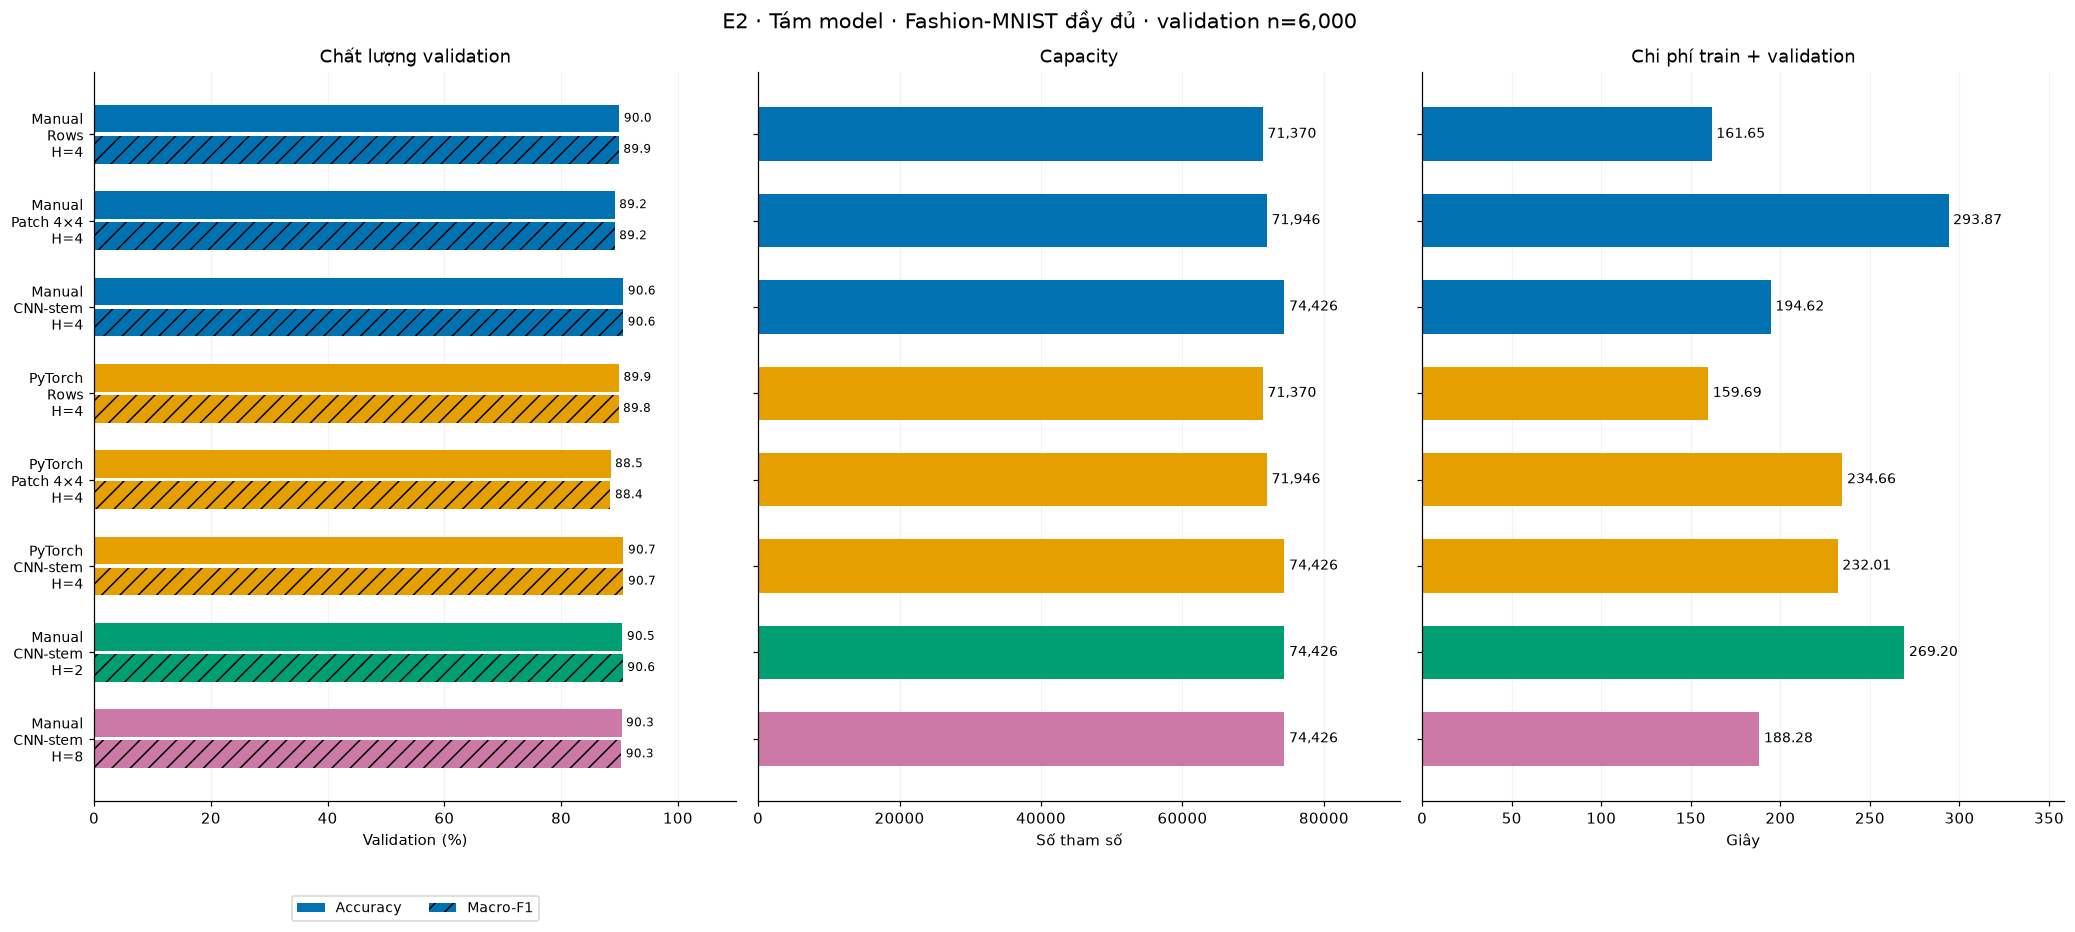

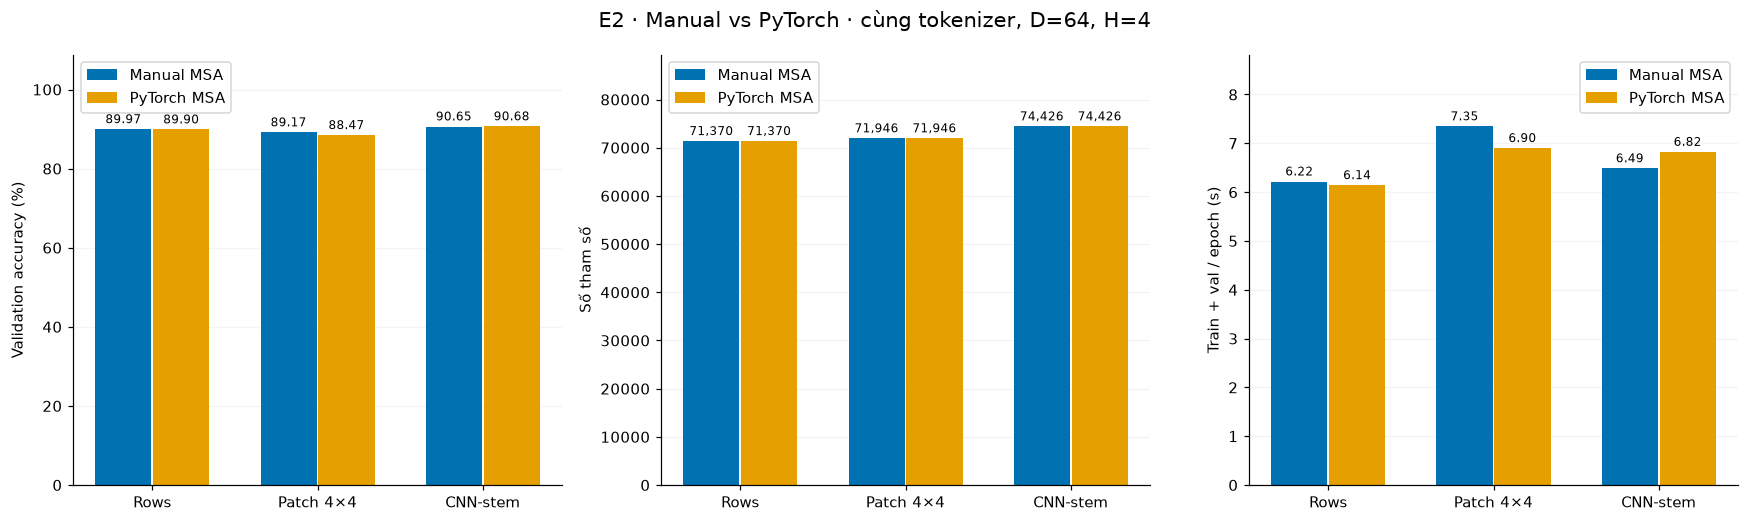

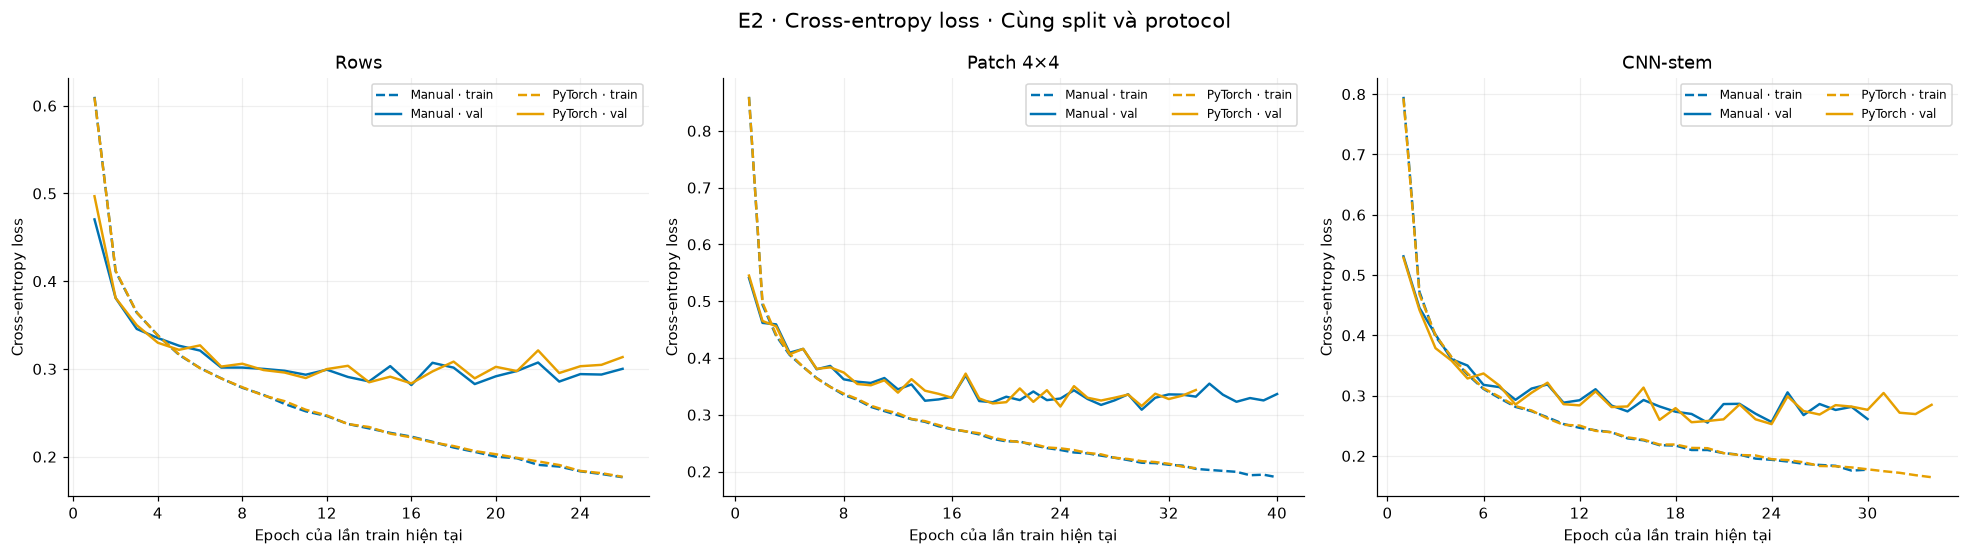

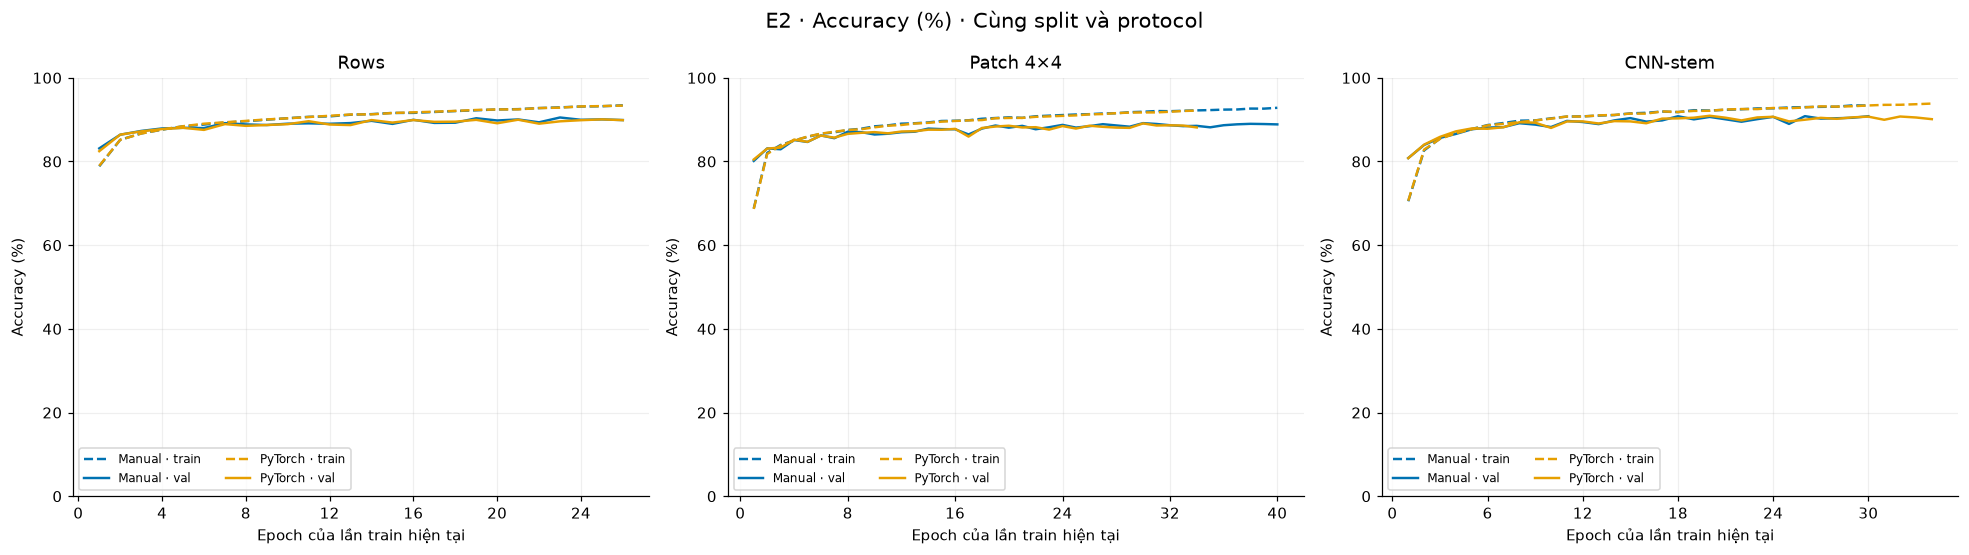

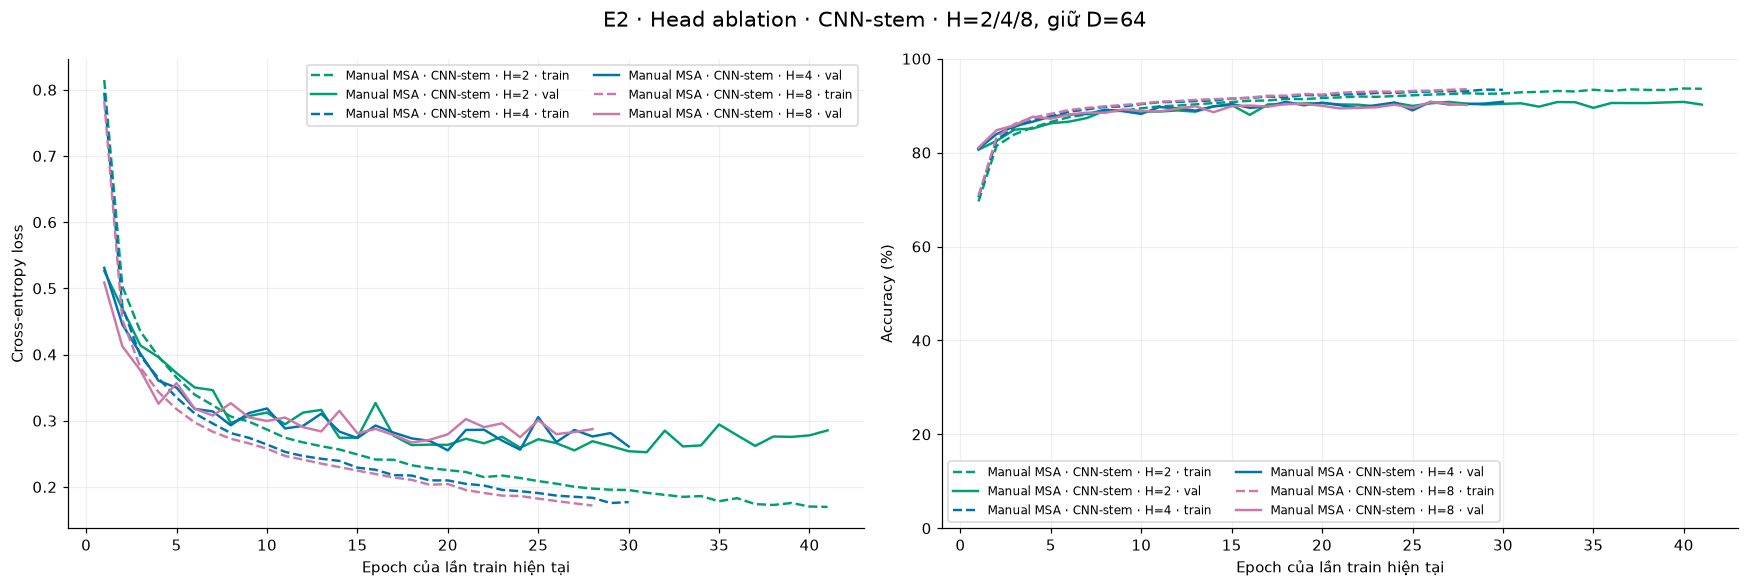

| Tokenizer | Manual val acc (%) | PyTorch val acc (%) | Manual − PyTorch (điểm %) | Manual / PyTorch s/epoch |
|---|---:|---:|---:|---|
| Rows | 89.97 | 89.90 | +0.07 | 6.217 / 6.142 |
| Patch 4×4 | 89.17 | 88.47 | +0.70 | 7.347 / 6.902 |
| CNN-stem | 90.65 | 90.68 | -0.03 | 6.487 / 6.824 |

In [11]:
log(
    "BẢNG KẾT QUẢ",
    "Trạng thái train, validation/test, capacity, thời gian và so sánh Manual/PyTorch cùng tokenizer.",
)
display_result_table(results, histories)
comparison_plot(results)
pairs = [(TOKEN_LABELS[t], f"manual_{t}", f"reference_{t}") for t in TOKEN_LABELS]
paired_comparison(
    results,
    pairs,
    ["Manual MSA", "PyTorch MSA"],
    "implementation_tokenizer_comparison",
    "Manual vs PyTorch · cùng tokenizer, D=64, H=4",
)
groups = [(TOKEN_LABELS[t], [f"manual_{t}", f"reference_{t}"]) for t in TOKEN_LABELS]
plot_curve_groups(histories, groups)
head_results = [
    next(r for r in results if r["run"] == run)
    for run in [head_runs[0], best_manual["run"], head_runs[1]]
]
plot_focus_curves(
    head_results,
    histories,
    "head_ablation_curves",
    f"Head ablation · {TOKEN_LABELS[best_tokenizer]} · H=2/4/8, giữ D=64",
)
lines = [
    "| Tokenizer | Manual val acc (%) | PyTorch val acc (%) | Manual − PyTorch (điểm %) | Manual / PyTorch s/epoch |",
    "|---|---:|---:|---:|---|",
]
by_run = {r["run"]: r for r in results}
for tokenizer, token_label in TOKEN_LABELS.items():
    mine, ref = by_run[f"manual_{tokenizer}"], by_run[f"reference_{tokenizer}"]
    lines.append(
        f"| {token_label} | {100 * mine['val_accuracy']:.2f} | {100 * ref['val_accuracy']:.2f} | {100 * (mine['val_accuracy'] - ref['val_accuracy']):+.2f} | {mine['seconds_per_epoch']:.3f} / {ref['seconds_per_epoch']:.3f} |"
    )
display(Markdown("\n".join(lines)))

## 9. Confusion matrix test và ảnh lỗi
Đủ 8 ma trận, mỗi cặp đặt ngang. Hàng thật/cột dự đoán, mỗi ô ghi số ảnh và % theo hàng; mỗi lớp test có 1.000 ảnh, cùng thang màu 0–100%. Ảnh lỗi gộp 4 model thuộc tokenizer chọn bằng validation; các ma trận số đủ 8 model giữ trong evaluations của kernel.

[02:58:20] [BÁO CÁO LỖI] Đủ 8 confusion matrix test; cặp Manual/PyTorch cùng tokenizer, rồi H=2/H=8.
[02:58:20] [CONFUSION MATRIX] Test: bốn cặp đặt ngang; mỗi ô = số ảnh và % theo hàng.
[HÌNH] confusion_test_pair_1 · hiển thị trong output cell
[HÌNH] confusion_test_pair_2 · hiển thị trong output cell
[HÌNH] confusion_test_pair_3 · hiển thị trong output cell
[HÌNH] confusion_test_pair_4 · hiển thị trong output cell
[02:58:23] [PHÂN TÍCH LỖI] Gộp 4 lớp có recall trung bình thấp nhất; mỗi hàng một model, mỗi cột cùng lớp thật.
[HÌNH] failure_examples_test · hiển thị trong output cell


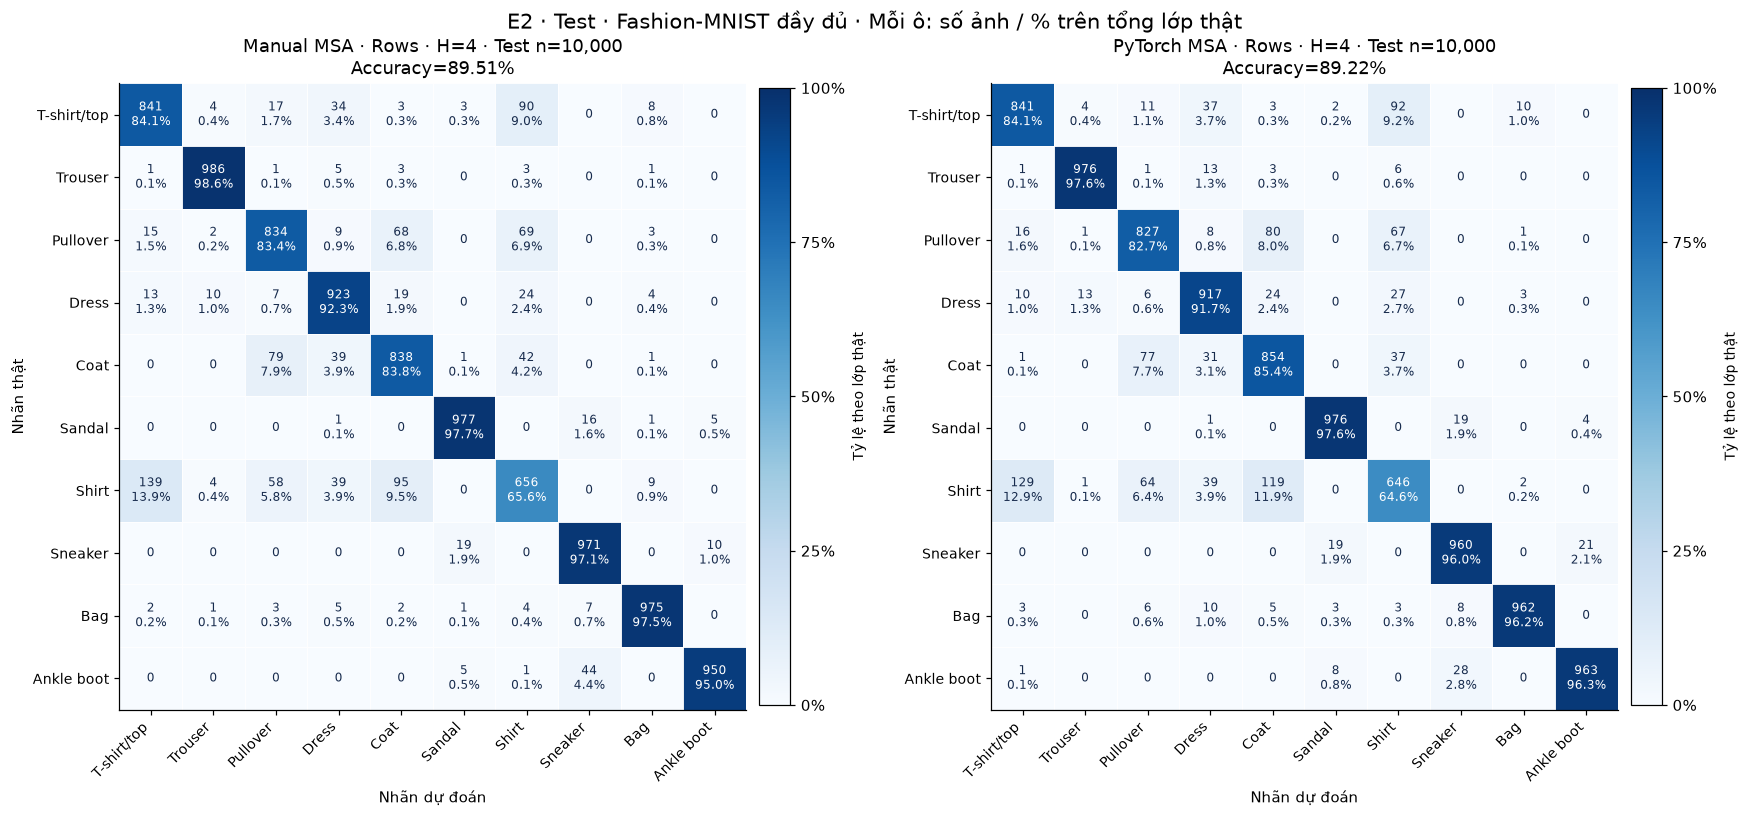

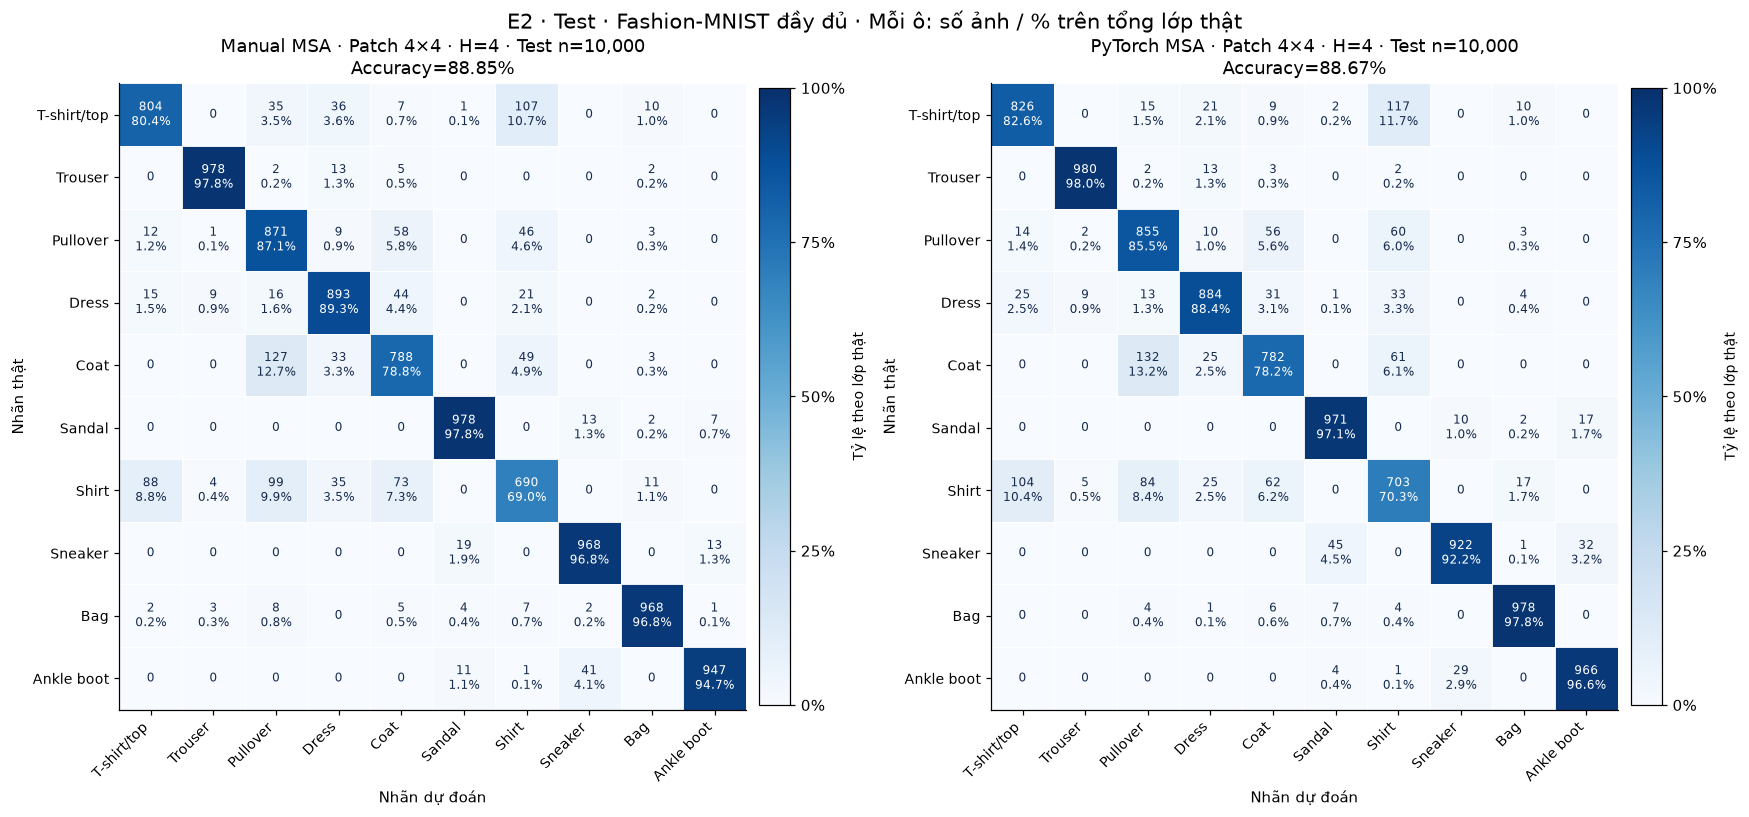

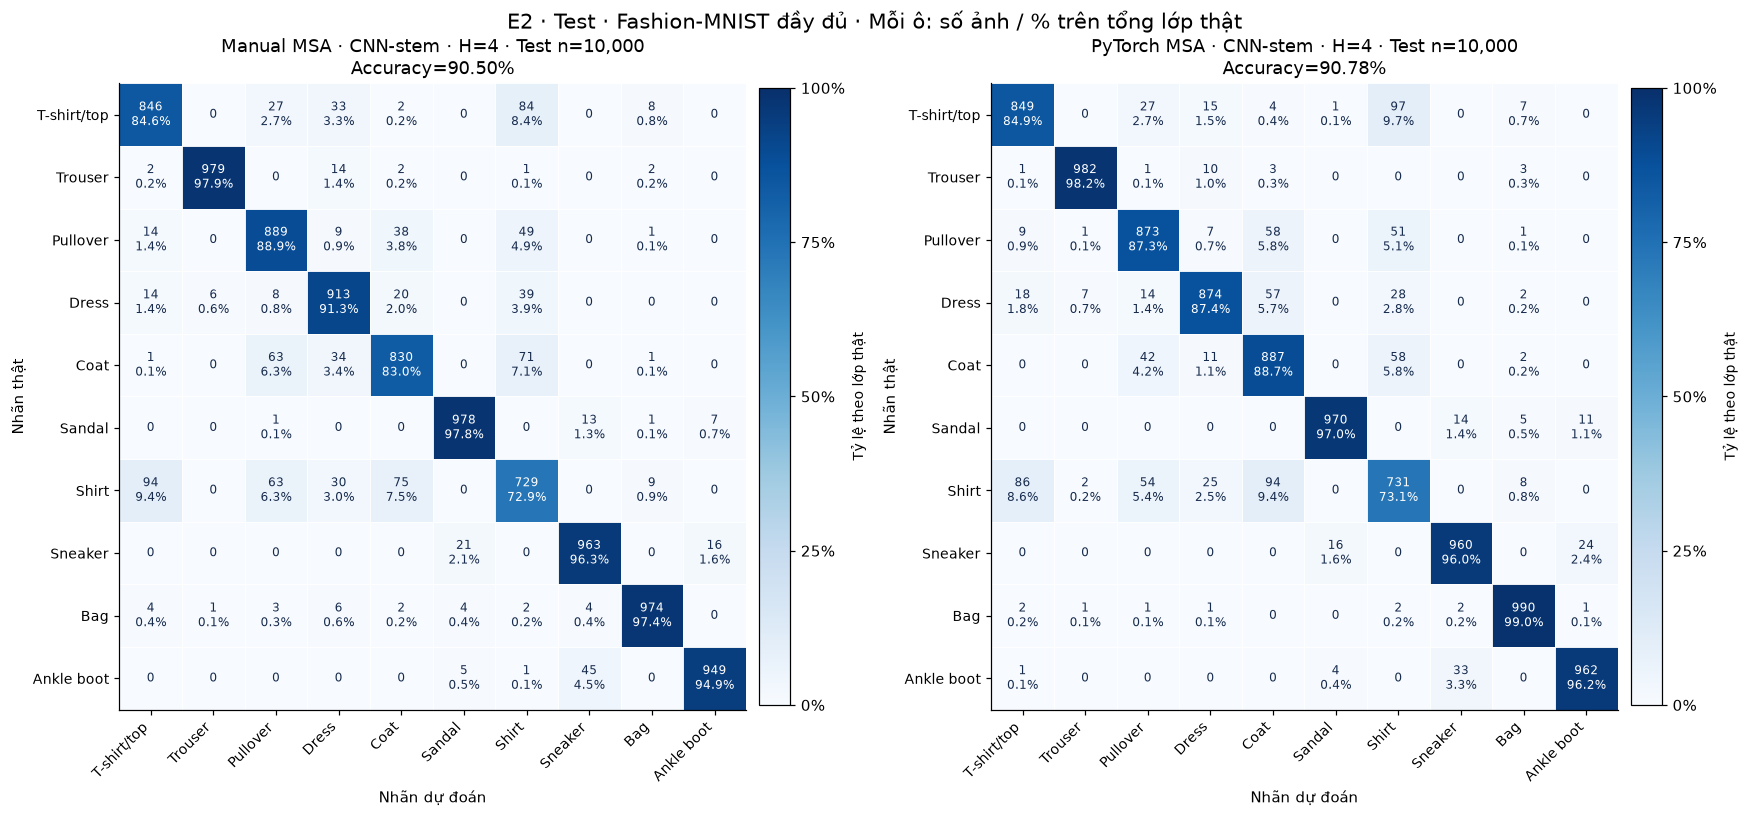

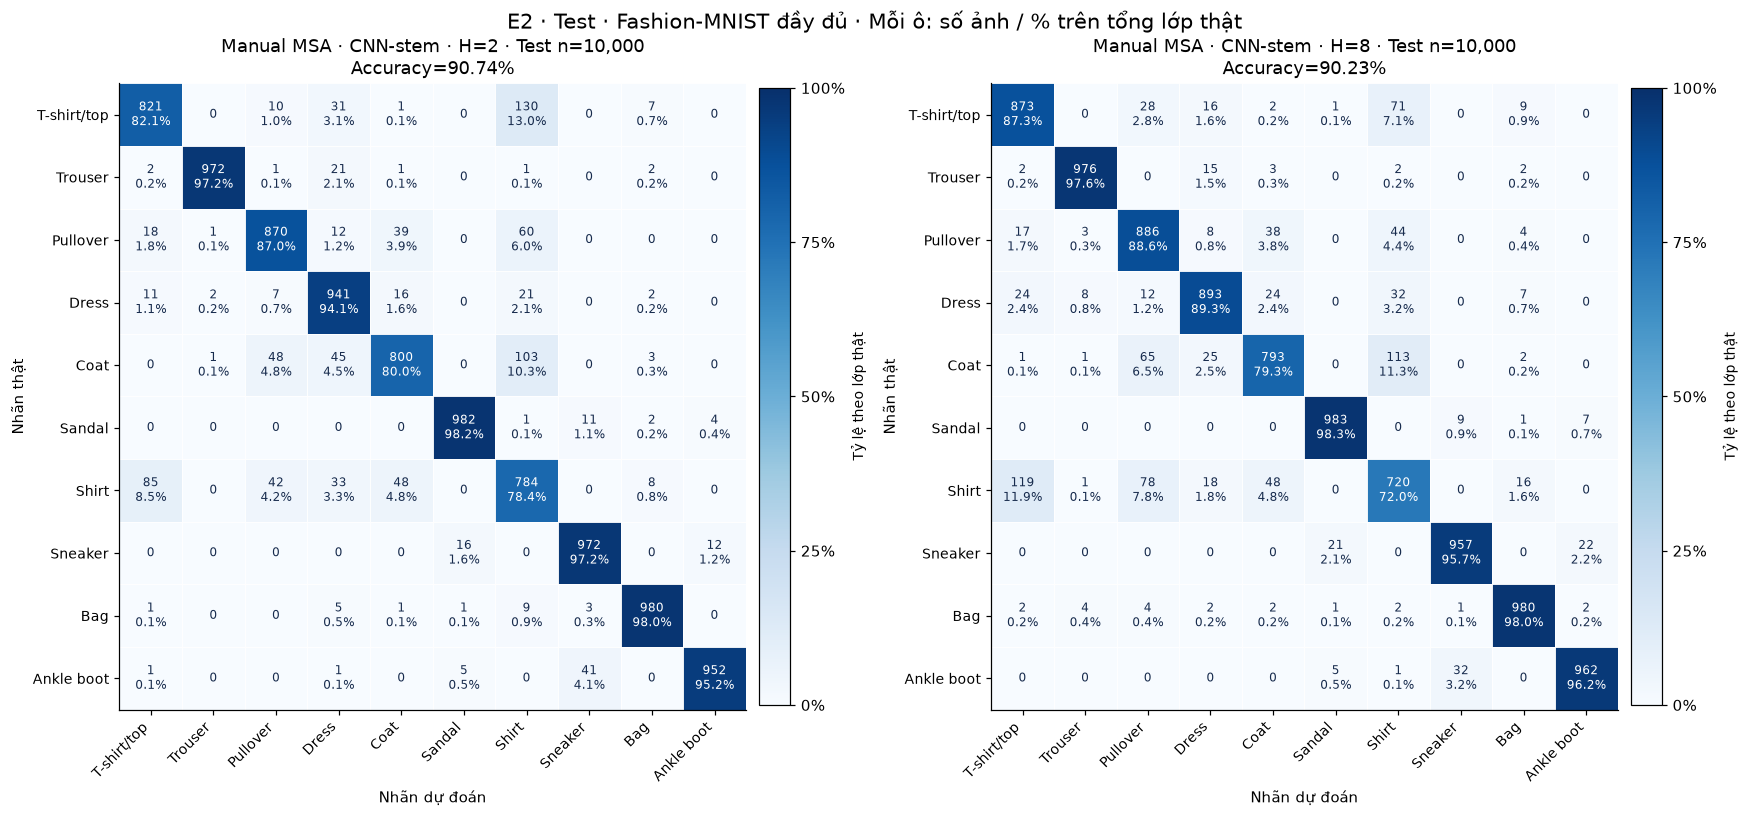

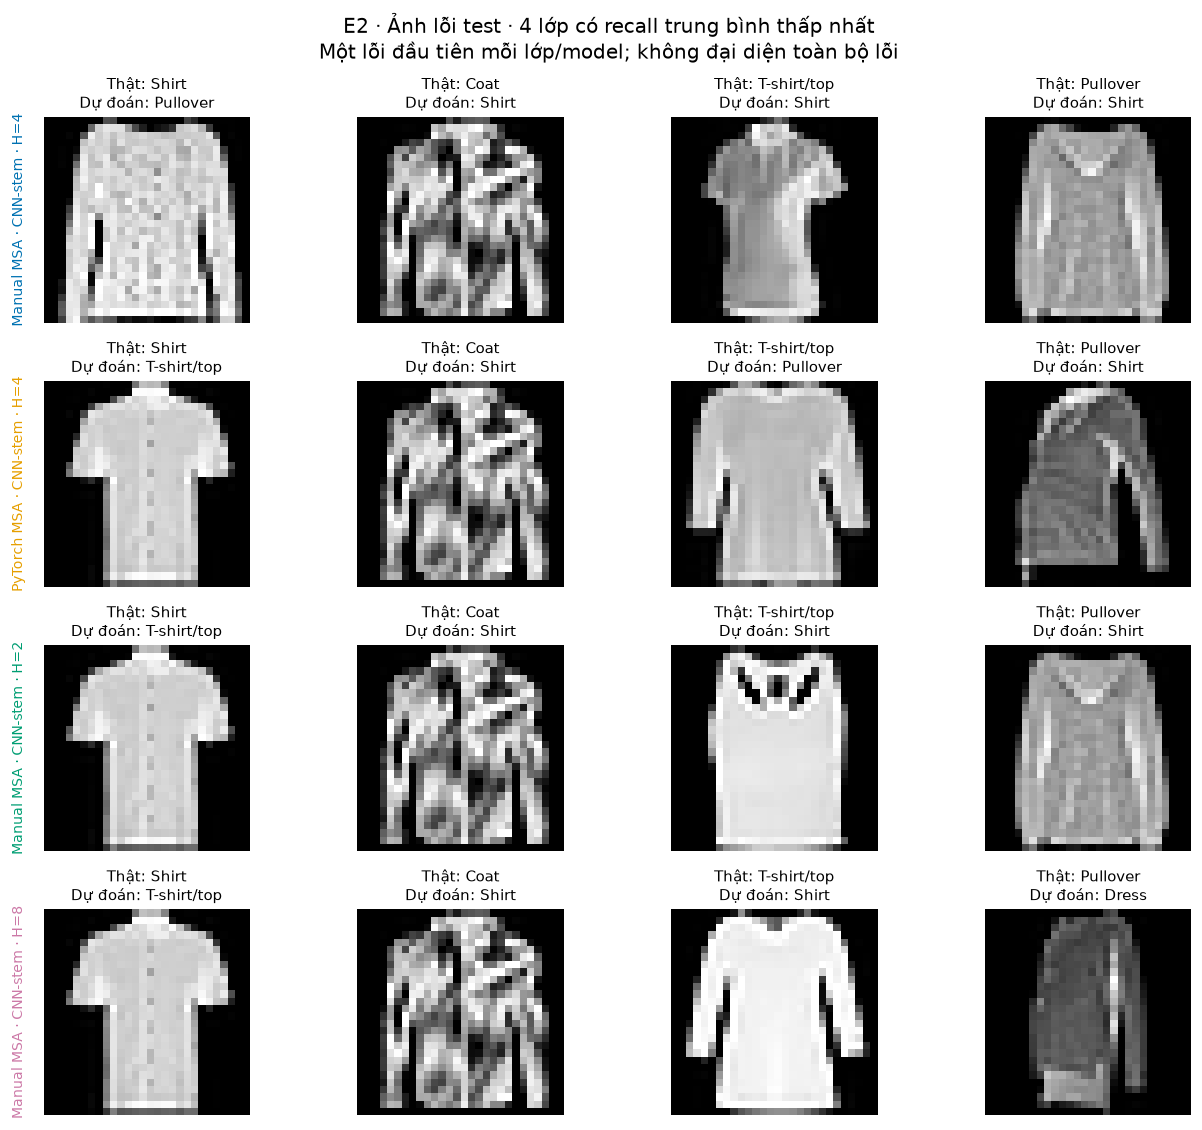

| Model | Nhầm nhiều nhất: thật → dự đoán | Số ảnh | % lớp thật |
|---|---|---:|---:|
| Manual MSA · Rows · H=4 | Shirt → T-shirt/top | 139 | 13.9% |
| Manual MSA · Patch 4×4 · H=4 | Coat → Pullover | 127 | 12.7% |
| Manual MSA · CNN-stem · H=4 | Shirt → T-shirt/top | 94 | 9.4% |
| PyTorch MSA · Rows · H=4 | Shirt → T-shirt/top | 129 | 12.9% |
| PyTorch MSA · Patch 4×4 · H=4 | Coat → Pullover | 132 | 13.2% |
| PyTorch MSA · CNN-stem · H=4 | T-shirt/top → Shirt | 97 | 9.7% |
| Manual MSA · CNN-stem · H=2 | T-shirt/top → Shirt | 130 | 13.0% |
| Manual MSA · CNN-stem · H=8 | Shirt → T-shirt/top | 119 | 11.9% |

In [12]:
log(
    "BÁO CÁO LỖI",
    "Đủ 8 confusion matrix test; cặp Manual/PyTorch cùng tokenizer, rồi H=2/H=8.",
)
by_run = {r["run"]: r for r in results}
ordered_runs = [
    run
    for tokenizer in TOKEN_LABELS
    for run in [f"manual_{tokenizer}", f"reference_{tokenizer}"]
] + head_runs
confusion_plots([by_run[run] for run in ordered_runs], evaluations, "test")
# Four representatives chosen by validation: same tokenizer, H=4 pair plus H=2/8.
error_runs = [best_manual["run"], f"reference_{best_tokenizer}", *head_runs]
failure_examples_plot([by_run[run] for run in error_runs], evaluations, "test")

report_error_pairs(results)

## 10. Attention của model manual đã chọn
Hai ảnh validation cố định: Shirt và Ankle boot. Map 28×28 hoặc 49×49 giữ đầy đủ trong biến attention của kernel. Để đọc được số, hình trình bày map gộp 7×7: query lấy trung bình, key lấy tổng, trung bình 4 head. Mỗi hàng vẫn tổng 100%. Đây là attention weight, không phải tương quan; entropy mô tả độ phân tán.

[02:58:23] [ATTENTION] Model manual H=4 đã chọn bằng validation; 2 ảnh cố định của lớp Shirt và Ankle boot.
[HÌNH] attention_best_manual · hiển thị trong output cell


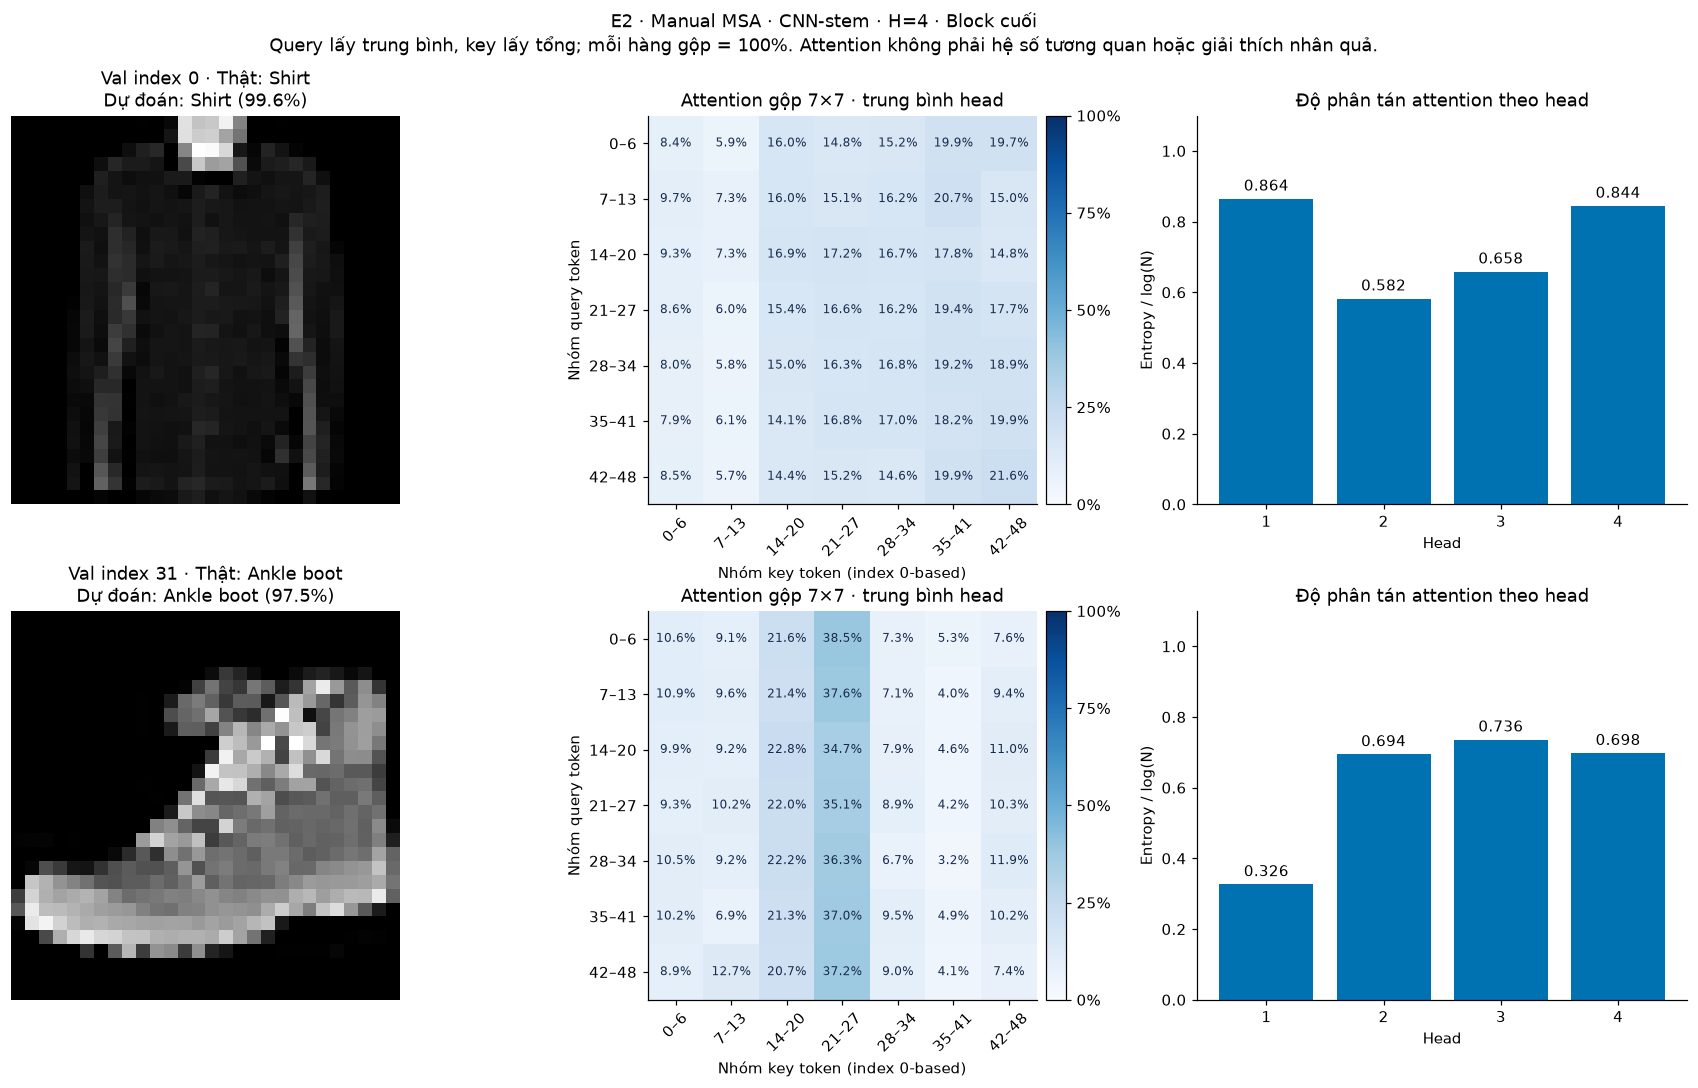

In [13]:
log(
    "ATTENTION",
    "Model manual H=4 đã chọn bằng validation; 2 ảnh cố định của lớp Shirt và Ankle boot.",
)
model = load_best_model(best_manual["run"])
labels = dataset_labels(val_set)
sample_indices = [int(np.flatnonzero(labels == label)[0]) for label in [6, 9]]
images = torch.stack([val_set[index][0] for index in sample_indices]).to(DEVICE)
with torch.no_grad():
    logits = model(images)
    probabilities = logits.softmax(1).cpu().numpy()
attention = model.blocks[-1].attn.attention.detach().cpu().numpy()
assert attention.shape[0] == 2 and attention.shape[1] == 4
np.testing.assert_allclose(attention.sum(-1), 1, atol=1e-5)

# 28 rows -> 7 groups of 4 rows; 49 spatial tokens -> 7 groups of 7 tokens.
# Mean across query tokens; sum across key tokens. Each grouped row still sums to 1.
token_count = attention.shape[-1]
group_size = token_count // 7
assert token_count in [28, 49]
groups = [np.arange(i * group_size, (i + 1) * group_size) for i in range(7)]
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
attention_records = []
for sample_number, sample_index in enumerate(sample_indices):
    truth = int(labels[sample_index])
    predicted = int(probabilities[sample_number].argmax())
    pixels = val_set[sample_index][0].squeeze().numpy() * std + mean
    axes[sample_number, 0].imshow(np.clip(pixels, 0, 1), cmap="gray", vmin=0, vmax=1)
    axes[sample_number, 0].set_title(
        f"Val index {sample_index} · Thật: {CLASS_NAMES[truth]}\nDự đoán: {CLASS_NAMES[predicted]} ({100 * probabilities[sample_number, predicted]:.1f}%)"
    )
    axes[sample_number, 0].axis("off")
    mean_attention = attention[sample_number].mean(0)
    grouped = np.array(
        [
            [mean_attention[np.ix_(query, key)].sum(1).mean() for key in groups]
            for query in groups
        ]
    )
    np.testing.assert_allclose(grouped.sum(1), 1, atol=1e-5)
    image = axes[sample_number, 1].imshow(grouped, cmap="Blues", vmin=0, vmax=1)
    for query in range(7):
        for key in range(7):
            axes[sample_number, 1].text(
                key,
                query,
                f"{100 * grouped[query, key]:.1f}%",
                ha="center",
                va="center",
                fontsize=8,
                color="white" if grouped[query, key] >= 0.55 else "#172B4D",
            )
    axes[sample_number, 1].set_xticks(
        range(7),
        [f"{i * group_size}–{(i + 1) * group_size - 1}" for i in range(7)],
        rotation=45,
    )
    axes[sample_number, 1].set_yticks(
        range(7), [f"{i * group_size}–{(i + 1) * group_size - 1}" for i in range(7)]
    )
    axes[sample_number, 1].set_xlabel("Nhóm key token (index 0-based)")
    axes[sample_number, 1].set_ylabel("Nhóm query token")
    axes[sample_number, 1].set_title("Attention gộp 7×7 · trung bình head")
    bar = fig.colorbar(image, ax=axes[sample_number, 1], fraction=0.046, pad=0.02)
    bar.set_ticks([0, 0.25, 0.5, 0.75, 1], labels=["0%", "25%", "50%", "75%", "100%"])
    safe_attention = np.maximum(attention[sample_number], 1e-12)
    entropy = -(safe_attention * np.log(safe_attention)).sum(-1).mean(-1) / math.log(
        token_count
    )
    bars = axes[sample_number, 2].bar(np.arange(1, 5), entropy, color="#0072B2")
    axes[sample_number, 2].bar_label(bars, fmt="%.3f", padding=3)
    axes[sample_number, 2].set_xticks(range(1, 5))
    axes[sample_number, 2].set_ylim(0, 1.1)
    axes[sample_number, 2].set_xlabel("Head")
    axes[sample_number, 2].set_ylabel("Entropy / log(N)")
    axes[sample_number, 2].set_title("Độ phân tán attention theo head")
    attention_records.append(
        {
            "validation_index": sample_index,
            "truth": truth,
            "prediction": predicted,
            "grouped_attention": grouped.tolist(),
            "normalized_head_entropy": entropy.tolist(),
        }
    )
fig.suptitle(
    f"E2 · {MODEL_LABELS[best_manual['run']]} · Block cuối\nQuery lấy trung bình, key lấy tổng; mỗi hàng gộp = 100%. Attention không phải hệ số tương quan hoặc giải thích nhân quả.",
    fontsize=12,
)
show_figure(fig, "attention_best_manual")

del model, images, logits
torch.cuda.empty_cache()

## 11. Nhận xét dựa trên số liệu thật
Đánh giá implementation/tokenizer/head, chi phí, capacity và train/validation gap. Phân tích được tính sau khi train/test, phân tích các so sánh từ metric đã đo.

In [14]:
log("NHẬN XÉT", "Tổng hợp số liệu thật cho implementation, tokenizer và số head.")
winner = max(
    results, key=lambda r: (r["val_accuracy"], r["val_macro_f1"], -r["val_loss"])
)
fastest = min(results, key=lambda r: r["seconds_per_epoch"])
best_head = max(
    head_results, key=lambda r: (r["val_accuracy"], r["val_macro_f1"], -r["val_loss"])
)
display(
    Markdown(
        f"**Toàn bộ dữ liệu:** 54.000 train / 6.000 validation / 10.000 test. Huấn luyện 8 model, "
        f"{sum(r['epochs_this_session'] for r in results)} epoch / {sum(r['optimizer_updates_this_session'] for r in results)} updates trên CUDA.\n\n"
        f"**Validation accuracy cao nhất:** {winner['model']} {100 * winner['val_accuracy']:.2f}%; "
        f"test tại checkpoint đó {100 * winner['test_accuracy']:.2f}%. "
        f"**Thời gian/epoch thấp nhất:** {fastest['model']} {fastest['seconds_per_epoch']:.3f}s.\n\n"
        f"**Head ablation:** tokenizer {TOKEN_LABELS[best_tokenizer]} chọn bằng validation trước test; "
        f"validation tốt nhất trong H=2/4/8 là {best_head['heads']} head ({100 * best_head['val_accuracy']:.2f}%). "
        "Giữ D=64 nên số tham số projection không tăng theo số head.\n\n"
        "**Diễn giải:** Rows N=28, patch/CNN-stem N=49; attention có chi phí theo N². "
        "CNN-stem thay đổi cả đặc trưng và capacity. Cặp Manual/PyTorch khởi tạo cùng weights. Parity forward/gradient khi cùng weights và tắt dropout "
        "không đảm bảo hai run training giống nhau: RNG/dropout và đường tối ưu có thể khác. "
        "Thời gian tổng còn phụ thuộc số epoch early stopping; xem thêm giây/epoch. "
        "Attention biểu thị trọng số trong phép kết hợp token; không tự chứng minh quan hệ nhân quả."
    )
)

gap_lines = [
    "| Model | Train acc tại best (%) | Val acc (%) | Train − val (điểm %) |",
    "|---|---:|---:|---:|",
]
confusion_lines = [
    "| Model | Nhầm nhiều nhất (thật → dự đoán) | Số ảnh | % lớp thật |",
    "|---|---|---:|---:|",
]
for result in results:
    best = next(
        row for row in histories[result["run"]] if row["epoch"] == result["best_epoch"]
    )
    gap_lines.append(
        f"| {result['model']} | {100 * best['train_accuracy']:.2f} | "
        f"{100 * result['val_accuracy']:.2f} | "
        f"{100 * (best['train_accuracy'] - result['val_accuracy']):+.2f} |"
    )
    cm = evaluations[result["run"]]["test"]["cm"]
    off_diagonal = cm.copy()
    np.fill_diagonal(off_diagonal, 0)
    truth, prediction = np.unravel_index(off_diagonal.argmax(), off_diagonal.shape)
    count = int(off_diagonal[truth, prediction])
    percentage = 100 * count / max(1, int(cm[truth].sum()))
    pair = (
        f"{CLASS_NAMES[truth]} → {CLASS_NAMES[prediction]}"
        if count
        else "Không có dự đoán sai"
    )
    confusion_lines.append(
        f"| {result['model']} | {pair} | {count} | {percentage:.1f}% |"
    )
display(
    Markdown("**Train/validation gap tại checkpoint chọn**\n\n" + "\n".join(gap_lines))
)
display(
    Markdown(
        "Train accuracy là số đo trong train mode khi cập nhật weights; validation "
        "dùng eval mode. Gap được đọc cùng learning curves và tác động của dropout, "
        "không đồng nhất với gap khi đánh giá lại train trong eval mode."
    )
)
display(
    Markdown(
        "**Các cặp lớp nhầm nhiều nhất trên test**\n\n" + "\n".join(confusion_lines)
    )
)
display(
    Markdown(
        "Tần suất nhầm lẫn được đo trên toàn bộ 10.000 ảnh test của từng model. "
        "Ảnh trong gallery minh họa những lỗi cụ thể, không đại diện cho phân bố lỗi. "
        "Thí nghiệm dùng một seed; chênh lệch nhỏ giữa các cấu hình chưa cho biết "
        "độ ổn định qua nhiều lần huấn luyện."
    )
)

finish_notebook()
log(
    "HOÀN TẤT E2",
    f"Hoàn tất {len(results)} model trên CUDA; kết quả nằm trong các output cell.",
)

[03:09:19] [NHẬN XÉT] Tổng hợp số liệu thật cho implementation, tokenizer và số head.


**Toàn bộ dữ liệu:** 54.000 train / 6.000 validation / 10.000 test. Huấn luyện 8 model, 259 epoch / 109290 updates trên CUDA.

**Validation accuracy cao nhất:** PyTorch MSA · CNN-stem · H=4 90.68%; test tại checkpoint đó 90.78%. **Thời gian/epoch thấp nhất:** PyTorch MSA · Rows · H=4 6.142s.

**Head ablation:** tokenizer CNN-stem chọn bằng validation trước test; validation tốt nhất trong H=2/4/8 là 4 head (90.65%). Giữ D=64 nên số tham số projection không tăng theo số head.

**Diễn giải:** Rows N=28, patch/CNN-stem N=49; attention có chi phí theo N². CNN-stem thay đổi cả đặc trưng và capacity. Cặp Manual/PyTorch khởi tạo cùng weights. Parity forward/gradient khi cùng weights và tắt dropout không đảm bảo hai run training giống nhau: RNG/dropout và đường tối ưu có thể khác. Thời gian tổng còn phụ thuộc số epoch early stopping; xem thêm giây/epoch. Attention biểu thị trọng số trong phép kết hợp token; không tự chứng minh quan hệ nhân quả.

**Train/validation gap tại checkpoint chọn**

| Model | Train acc tại best (%) | Val acc (%) | Train − val (điểm %) |
|---|---:|---:|---:|
| Manual MSA · Rows · H=4 | 91.61 | 89.97 | +1.65 |
| Manual MSA · Patch 4×4 · H=4 | 91.89 | 89.17 | +2.72 |
| Manual MSA · CNN-stem · H=4 | 92.18 | 90.65 | +1.53 |
| PyTorch MSA · Rows · H=4 | 91.75 | 89.90 | +1.85 |
| PyTorch MSA · Patch 4×4 · H=4 | 90.90 | 88.47 | +2.44 |
| PyTorch MSA · CNN-stem · H=4 | 92.79 | 90.68 | +2.10 |
| Manual MSA · CNN-stem · H=2 | 92.84 | 90.50 | +2.34 |
| Manual MSA · CNN-stem · H=8 | 92.13 | 90.35 | +1.78 |

Train accuracy là số đo trong train mode khi cập nhật weights; validation dùng eval mode. Gap được đọc cùng learning curves và tác động của dropout, không đồng nhất với gap khi đánh giá lại train trong eval mode.

**Các cặp lớp nhầm nhiều nhất trên test**

| Model | Nhầm nhiều nhất (thật → dự đoán) | Số ảnh | % lớp thật |
|---|---|---:|---:|
| Manual MSA · Rows · H=4 | Shirt → T-shirt/top | 139 | 13.9% |
| Manual MSA · Patch 4×4 · H=4 | Coat → Pullover | 127 | 12.7% |
| Manual MSA · CNN-stem · H=4 | Shirt → T-shirt/top | 94 | 9.4% |
| PyTorch MSA · Rows · H=4 | Shirt → T-shirt/top | 129 | 12.9% |
| PyTorch MSA · Patch 4×4 · H=4 | Coat → Pullover | 132 | 13.2% |
| PyTorch MSA · CNN-stem · H=4 | T-shirt/top → Shirt | 97 | 9.7% |
| Manual MSA · CNN-stem · H=2 | T-shirt/top → Shirt | 130 | 13.0% |
| Manual MSA · CNN-stem · H=8 | Shirt → T-shirt/top | 119 | 11.9% |

Tần suất nhầm lẫn được đo trên toàn bộ 10.000 ảnh test của từng model. Ảnh trong gallery minh họa những lỗi cụ thể, không đại diện cho phân bố lỗi. Thí nghiệm dùng một seed; chênh lệch nhỏ giữa các cấu hình chưa cho biết độ ổn định qua nhiều lần huấn luyện.

[03:09:19] [THÍ NGHIỆM] Hoàn tất đánh giá 8 model trên toàn bộ test.


[03:09:19] [HOÀN TẤT E2] Hoàn tất 8 model trên CUDA; kết quả nằm trong các output cell.



## 12. Tái lập thí nghiệm

Chọn kernel **Python 3.14 có PyTorch CUDA**, mở notebook trong `source_code`,
rồi **Restart Kernel → Run All**. Dữ liệu: toàn bộ Fashion-MNIST đã chia thành
54.000 train / 6.000 validation / 10.000 test. Seed42, AdamW, batch128;
giới hạn100 epoch, patience4, min_delta0,0001.

Code, training loop, kiểm chứng và trình bày kết quả nằm trong notebook này.
`RUN_CONFIGS` giữ cấu hình mỗi model; `histories` giữ metric từng epoch;
`evaluations` giữ ma trận và ví dụ lỗi; `EXECUTION_LOG` giữ log chi tiết trong RAM.
Checkpoint tốt nhất giữ trong CPU RAM cho đến khi hoàn tất đánh giá.

Bảng, hình, tiến trình và nhận xét hiển thị trong output cell.
**Save notebook** để lưu toàn bộ kết quả vào file `.ipynb`.
Nguồn dữ liệu và định dạng: [datasets/README](../datasets/README.md).
Đề bài: [exercise-vne.pdf](../assignment/exercise-vne.pdf).

Người thực hiện cần kiểm chứng, giải thích code/số liệu và khai báo phần AI hỗ trợ
theo mục1.6 của đề trước khi nộp.
